# **Pneumonia Detection**
**A machine learning project for detecting pneumonia from chest X-ray images using transfer learning and model tuning techniques.**

## **Pretrained Model Tuning**

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix,
  ConfusionMatrixDisplay,
  roc_curve,
  auc,
  precision_recall_curve,
  average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from matplotlib import pyplot as plt
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### **Dataset Preparation**
We'll create a custom dataset class to handle our X-ray images and apply appropriate transformations for transfer learning.

In [2]:
# Import data loading function
from _data import load_brain_tumor_1d


class BrainTumorDataset(Dataset):
  def __init__(self, features, labels, transform=None):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    image = self.features[idx]
    label = self.labels[idx]

    # Convert to tensor if not already
    if not torch.is_tensor(image):
      image = torch.tensor(image, dtype=torch.float32)

    # Reshape to (1, 224, 224) if necessary
    if image.shape != (1, 224, 224):
      image = image.reshape(1, 224, 224)

    # Apply transformations if any
    if self.transform:
      image = self.transform(image)

    return image, label

### **Data Loading & Transformation**
Define the transformations needed for pretrained models and load our dataset.

In [3]:
# Define transformations for transfer learning
train_transforms = transforms.Compose(
  [
    # Convert grayscale to RGB (needed for pretrained models that expect 3 channels)
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    # Data augmentation
    transforms.RandomHorizontalFlip(),  # Horizontal flips are safe for chest X-rays
    transforms.RandomRotation(5),  # Small rotation angle
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Small translations
    # Normalize using ImageNet stats (required for pretrained models)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ]
)

test_transforms = transforms.Compose(
  [
    # Convert grayscale to RGB
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    # Normalize using ImageNet stats
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ]
)

# Load data
train_data, test_data = load_brain_tumor_1d(
  include_raw=True, include_hog=False, include_lbp=False, pca_mode="none"
)
print(train_data.shape)
print(test_data.shape)

# Split features and labels
X_train = train_data[:, :-1].reshape(-1, 1, 224, 224)
y_train = train_data[:, -1]
X_test = test_data[:, :-1].reshape(-1, 1, 224, 224)
y_test = test_data[:, -1]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = BrainTumorDataset(X_train, y_train, transform=train_transforms)
test_dataset = BrainTumorDataset(X_test, y_test, transform=test_transforms)

# Create data loaders
trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

(5712, 50177)
(1311, 50177)


### **Training Utilities**
Define helper functions for the training process.

In [4]:
def make_train_step(model, optimizer, loss_fn):
  """
  Create a single training step function to update model parameters
  """

  def train_step(x, y):
    model.train()
    yhat = model(x)
    loss = loss_fn(yhat, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return loss.item()

  return train_step


def evaluate_model(model, dataloader, loss_fn, device, num_classes=4):
  model.eval()
  all_preds = []
  all_targets = []
  all_probs = []
  cum_loss = 0
  with torch.no_grad():
    for x_batch, y_batch in dataloader:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      yhat = model(x_batch)
      val_loss = loss_fn(yhat, y_batch)
      cum_loss += val_loss.item() / len(dataloader)

      # Softmax for probabilities, argmax for predictions
      probs = torch.softmax(yhat, dim=1)
      preds = torch.argmax(probs, dim=1)

      all_probs.append(probs.cpu())
      all_preds.append(preds.cpu())
      all_targets.append(y_batch.cpu())

  # Combine all batches
  all_preds = torch.cat(all_preds).numpy()
  all_targets = torch.cat(all_targets).numpy()
  all_probs = torch.cat(all_probs).numpy()

  # Compute metrics
  metrics = {
    "loss": cum_loss,
    "accuracy": accuracy_score(all_targets, all_preds),
    "precision": precision_score(all_targets, all_preds, average='weighted', zero_division=0),
    "recall": recall_score(all_targets, all_preds, average='weighted', zero_division=0),
    "f1": f1_score(all_targets, all_preds, average='weighted', zero_division=0),
    "predictions": all_preds,
    "targets": all_targets,
    "probs": all_probs,
  }

  return metrics


def plot_metrics(train_losses, val_losses, val_metrics, title_prefix="Model"):
  """
  Plot training and validation metrics
  """
  plt.figure(figsize=(13, 13))

  # Plot losses
  plt.subplot(2, 2, 1)
  plt.plot(train_losses, label="Train Loss")
  plt.plot(val_losses, label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(f"{title_prefix} - Loss over Epochs")
  plt.legend()
  plt.grid(True)

  # Plot accuracy
  plt.subplot(2, 2, 2)
  plt.plot([metrics["accuracy"] for metrics in val_metrics])
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title(f"{title_prefix} - Validation Accuracy")
  plt.grid(True)

  # Plot F1 score
  plt.subplot(2, 2, 3)
  plt.plot([metrics["f1"] for metrics in val_metrics])
  plt.xlabel("Epoch")
  plt.ylabel("F1 Score")
  plt.title(f"{title_prefix} - Validation F1 Score")
  plt.grid(True)

  # Plot precision and recall
  plt.subplot(2, 2, 4)
  plt.plot([metrics["precision"] for metrics in val_metrics], label="Precision")
  plt.plot([metrics["recall"] for metrics in val_metrics], label="Recall")
  plt.xlabel("Epoch")
  plt.ylabel("Score")
  plt.title(f"{title_prefix} - Validation Precision and Recall")
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()


def plot_learning_curve(
  train_metrics_history, val_metrics_history, ax, title="Learning Curve"
):
  epochs = np.arange(1, len(val_metrics_history) + 1)
  train_f1_scores = [metrics["f1"] for metrics in train_metrics_history]
  val_f1_scores = [metrics["f1"] for metrics in val_metrics_history]

  # Calculate moving standard deviation with window size of 3
  # This simulates variance you might see across different runs
  def moving_std(data, window=3):
    if len(data) < window:
      return np.zeros_like(data)
    result = np.zeros_like(data)
    for i in range(len(data)):
      start = max(0, i - window // 2)
      end = min(len(data), i + window // 2 + 1)
      result[i] = np.std(data[start:end])
    return result

  train_std = moving_std(train_f1_scores)
  val_std = moving_std(val_f1_scores)

  ax.grid(True)
  ax.set_xlim(0.5, len(epochs) + 0.5)
  ax.set_xlabel("Epochs")
  ax.set_ylim(0.0, 1.05)
  ax.set_ylabel("F1 Score")

  ax.fill_between(
    epochs,
    np.array(train_f1_scores) - train_std,
    np.array(train_f1_scores) + train_std,
    alpha=0.1,
    color="r",
  )

  ax.fill_between(
    epochs,
    np.array(val_f1_scores) - val_std,
    np.array(val_f1_scores) + val_std,
    alpha=0.1,
    color="g",
  )

  ax.plot(epochs, train_f1_scores, "o-", color="r", label="Training F1 Score")
  ax.plot(epochs, val_f1_scores, "o-", color="g", label="Validation F1 Score")

  ax.legend(loc="best")
  ax.set_title(title)


def plot_confusion_matrix(y_true, y_pred, ax, title="Confusion Matrix", num_classes=4):
  """
  Plot confusion matrix
  """
  labels = ["glioma", "meningioma", "notumor", "pituitary"][:num_classes]
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(cm, display_labels=labels)
  disp.plot(cmap=plt.cm.Blues, ax=ax)
  disp.ax_.set_title(title)
  disp.ax_.set_xlabel("Predicted Label")
  disp.ax_.set_ylabel("True Label")

def plot_multiclass_roc(y_true, y_probs, ax, title="ROC Curves", num_classes=4):
    """Plot ROC curve for each class (one-vs-rest)"""
        
    labels = ["glioma", "meningioma", "notumor", "pituitary"][:num_classes]
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True)

# def plot_aucroc_curve(y_true, y_scores, ax, title="ROC Curve"):
#   fpr, tpr, _ = roc_curve(y_true, y_scores)
#   roc_auc = auc(fpr, tpr)
#   pd.DataFrame({"fpr": fpr, "tpr": tpr}).plot(
#     "fpr",
#     "tpr",
#     xlabel="False Positive Rate",
#     ylabel="True Positive Rate",
#     label=f"AUC = {roc_auc:.3f}",
#     xlim=[0.0, 1.05],
#     ylim=[0.0, 1.05],
#     grid=True,
#     title=title,
#     ax=ax,
#   )
#   ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
#   ax.legend(loc="lower right")



def plot_multiclass_prcrcl(y_true, y_probs, ax, title="Precision-Recall Curves", num_classes=4):
    labels = ["glioma", "meningioma", "notumor", "pituitary"][:num_classes]

    # Binarize labels for one-vs-rest
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    for i in range(num_classes):
        # Precision-Recall for this class vs rest
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        avg_precision = average_precision_score(y_true_bin[:, i], y_probs[:, i])

        ax.plot(
            recall,
            precision,
            label=f"{labels[i]} (AP = {avg_precision:.3f})"
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.set_xlim([0.0, 1.05])
    ax.set_ylim([0.0, 1.05])
    ax.grid(True)
    ax.legend(loc="lower left")



# def plot_prcrcl_curve(y_true, y_scores, ax, title="Precision-Recall Curve"):
#   # Calculate precision, recall, and AP
#   precision, recall, _ = precision_recall_curve(y_true, y_scores)
#   avg_precision = average_precision_score(y_true, y_scores)

#   pd.DataFrame({"recall": recall, "precision": precision}).plot(
#     "recall",
#     "precision",
#     xlabel="Recall",
#     ylabel="Precision",
#     label=f"AP = {avg_precision:.3f}",
#     xlim=[0.0, 1.05],
#     ylim=[0.0, 1.05],
#     grid=True,
#     title=title,
#     ax=ax,
#   )
#   no_skill = np.sum(y_true) / len(y_true)
#   ax.plot([0, 1], [no_skill, no_skill], color="gray", linestyle="--")
#   ax.legend(loc="lower left")

### **Model Architecture**
Load pretrained models and modify them for our pneumonia classification task.

In [5]:
def create_resnet_model(num_classes=4):
  """
  Create a ResNet18 model with pretrained weights
  """
  # Load pretrained ResNet18
  model = torchvision.models.resnet18(weights="IMAGENET1K_V1")

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  for param in model.layer4.parameters():
    param.requires_grad = True

  # Replace the final layer for binary classification
  num_ftrs = model.fc.in_features
  model.fc = nn.Linear(num_ftrs, num_classes)  # Binary output

  return model.to(device)


def create_densenet_model(num_classes=4):
  """
  Create a DenseNet121 model with pretrained weights
  """
  # Load pretrained DenseNet121
  model = torchvision.models.densenet121(weights="IMAGENET1K_V1")

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  for param in model.features.denseblock4.parameters():
    param.requires_grad = True
  for param in model.features.norm5.parameters():
    param.requires_grad = True

  # Replace the final layer for binary classification
  num_ftrs = model.classifier.in_features
  model.classifier = nn.Linear(num_ftrs, num_classes)  # Binary output

  return model.to(device)


def create_efficientnet_model(num_classes=4):
  """
  Create an EfficientNet-B0 model with pretrained weights
  """
  # Load pretrained EfficientNet B0
  model = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  for i in range(6, 8):
    for param in model.features[i].parameters():
      param.requires_grad = True

  # Replace the classifier for binary classification
  num_ftrs = model.classifier[1].in_features
  model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), nn.Linear(num_ftrs, num_classes)
  )

  return model.to(device)


def create_vit_model(num_classes=4):
  """
  Create a Vision Transformer (ViT) model with pretrained weights
  """
  # Load pretrained ViT-B/16
  model = torchvision.models.vit_b_16(weights="IMAGENET1K_V1")

  num_blocks = len(model.encoder.layers)
  for i in range(num_blocks - 2, num_blocks):
    for param in model.encoder.layers[i].parameters():
      param.requires_grad = True

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  # Replace the final layer for binary classification
  num_ftrs = model.heads.head.in_features
  model.heads.head = nn.Linear(num_ftrs, num_classes)  # Binary output

  return model.to(device)


def create_swin_model(num_classes=4):
  """
  Create a Swin Transformer model with pretrained weights
  """
  # Load pretrained Swin-T
  model = torchvision.models.swin_t(weights="IMAGENET1K_V1")

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  for param in model.features[-1].parameters():
    param.requires_grad = True

  # Replace the final layer for binary classification
  num_ftrs = model.head.in_features
  model.head = nn.Linear(num_ftrs, num_classes)  # Binary output

  return model.to(device)


def create_convnext_model(num_classes):
  """
  Create a ConvNeXt model with pretrained weights
  """
  # Load pretrained ConvNeXt-T
  model = torchvision.models.convnext_tiny(weights="IMAGENET1K_V1")

  # Freeze all parameters
  for param in model.parameters():
    param.requires_grad = False

  for param in model.features[-2].parameters():  # Last stage before norm layer
    param.requires_grad = True

  # Replace the final layer for binary classification
  num_ftrs = model.classifier[2].in_features
  model.classifier = nn.Sequential(
    nn.Flatten(1), nn.LayerNorm([num_ftrs]), nn.Linear(num_ftrs, num_classes)
  )

  return model.to(device)

### **Training Loop**
Define the training process with early stopping and learning rate scheduling.

In [6]:
def train_model(
  model, trainloader, testloader, model_name="Model", n_epochs=20, patience=3, num_classes=4
):
  # Calculate class weights for balanced loss
  y_train_np = y_train.cpu().numpy()
  class_weights = compute_class_weight(
    "balanced", classes=np.arange(num_classes), y=y_train_np.flatten()
  )
  pos_weight = torch.tensor(class_weights, dtype=torch.float32).to(device)
  print(f"Class weights: {class_weights}")
  # print(f"Positive class weight: {pos_weight.item()}")

  # Loss function and optimizer
  loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
  optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
  )
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, "min", patience=2, factor=0.5
  )

  # Training step function
  train_step = make_train_step(model, optimizer, loss_fn)

  # Initialize tracking variables
  best_loss = float("inf")
  early_stopping_counter = 0
  best_model_weights = None

  train_losses = []
  val_losses = []
  train_metrics_history = []
  val_metrics_history = []

  # Training loop
  for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_loss = 0
    all_train_outputs = []
    all_train_targets = []
    for i, data in tqdm(
      enumerate(trainloader),
      total=len(trainloader),
      desc=f"Epoch {epoch + 1}/{n_epochs}",
    ):
      x_batch, y_batch = data
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      loss = train_step(x_batch, y_batch)
      epoch_loss += loss / len(trainloader)

      with torch.no_grad():
        outputs = model(x_batch)
        all_train_outputs.append(outputs.cpu())
        all_train_targets.append(y_batch.cpu())

    train_losses.append(epoch_loss)
    with torch.no_grad():
      model.eval()  # Set model to evaluation mode
      all_train_outputs = torch.cat(all_train_outputs, dim=0)
      all_train_targets = torch.cat(all_train_targets, dim=0)

      # Convert outputs to probabilities
      train_probs = torch.softmax(all_train_outputs, dim=1).numpy()
      train_preds = np.argmax(train_probs, axis=1)
      train_targets = all_train_targets.numpy()

      # Calculate metrics
      train_metrics = {
        "loss": epoch_loss,
        "accuracy": accuracy_score(train_targets, train_preds),
        "precision": precision_score(train_targets, train_preds, average='weighted', zero_division=0),
        "recall": recall_score(train_targets, train_preds, average='weighted', zero_division=0),
        "f1": f1_score(train_targets, train_preds, average='weighted', zero_division=0),
        "probs": train_probs,
        "predictions": train_preds,
        "targets": train_targets,
      }

      train_metrics_history.append(train_metrics)

    print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {epoch_loss:.4f}")
    print(
      f"Training Accuracy: {train_metrics['accuracy']:.4f}, "
      f"Precision: {train_metrics['precision']:.4f}, Recall: {train_metrics['recall']:.4f}, "
      f"F1 Score: {train_metrics['f1']:.4f}"
    )

    # Validation phase
    val_metrics = evaluate_model(model, testloader, loss_fn, device, num_classes=num_classes)
    val_loss = val_metrics["loss"]
    val_losses.append(val_loss)
    val_metrics_history.append(val_metrics)

    print(
      f"Validation Loss: {val_loss:.4f}, Accuracy: {val_metrics['accuracy']:.4f}, "
      f"Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, "
      f"F1 Score: {val_metrics['f1']:.4f}"
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Check for improvement and early stopping
    if val_loss < best_loss:
      best_loss = val_loss
      best_model_weights = model.state_dict().copy()
      early_stopping_counter = 0
      print(f"New best validation loss: {best_loss:.4f}")
    else:
      early_stopping_counter += 1
      print(f"No improvement for {early_stopping_counter} epochs")

    if early_stopping_counter >= patience:
      print("Early stopping triggered")
      break

  # Load best model weights
  if best_model_weights:
    model.load_state_dict(best_model_weights)
    print(f"Loaded best model with validation loss: {best_loss:.4f}")

  # Final evaluation
  final_metrics = evaluate_model(
    model, testloader, loss_fn, device,  num_classes=num_classes
  )
  print("\n=== Final Model Evaluation ===")
  print(f"Loss: {final_metrics['loss']:.4f}")
  print(f"Accuracy: {final_metrics['accuracy']:.4f}")
  print(f"Precision: {final_metrics['precision']:.4f}")
  print(f"Recall: {final_metrics['recall']:.4f}")
  print(f"F1 Score: {final_metrics['f1']:.4f}")

  # Plot metrics
  plot_metrics(train_losses, val_losses, val_metrics_history, title_prefix=model_name)

  # Plot confusion matrix
  _, axs = plt.subplots(1, 4, figsize=(26, 6.5))
  plot_learning_curve(
    train_metrics_history,
    val_metrics_history,
    ax=axs[0],
    title=f"{model_name} Learning Curve",
  )
  plot_confusion_matrix(
    final_metrics["targets"],
    final_metrics["predictions"],
    ax=axs[1],
    title=f"{model_name} Confusion Matrix",
    num_classes=num_classes
  )
  # For multi-class, you might want per-class ROC or skip it
  plot_multiclass_roc(
      final_metrics["targets"],
      final_metrics["probs"],
      ax=axs[2],
      title=f"{model_name} ROC Curves",
      num_classes=num_classes
  )

  plot_multiclass_prcrcl(
    final_metrics["targets"],
    final_metrics["probs"],
    ax=axs[3],
    title=f"{model_name} Precision-Recall Curve",
    num_classes=num_classes
  )

  plt.tight_layout()
  plt.show()

  return model, final_metrics

### **Model Tuning: ResNet18**
Train and evaluate a fine-tuned ResNet18 model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]


Epoch 1/20: 100%|██████████| 179/179 [04:23<00:00,  1.47s/it]


Epoch 1/20, Training Loss: 0.7682
Training Accuracy: 0.7171, Precision: 0.7230, Recall: 0.7171, F1 Score: 0.7190
Validation Loss: 1.3152, Accuracy: 0.5584, Precision: 0.7354, Recall: 0.5584, F1 Score: 0.5509
New best validation loss: 1.3152


Epoch 2/20: 100%|██████████| 179/179 [04:19<00:00,  1.45s/it]


Epoch 2/20, Training Loss: 0.6171
Training Accuracy: 0.7659, Precision: 0.7752, Recall: 0.7659, F1 Score: 0.7691
Validation Loss: 0.7528, Accuracy: 0.7353, Precision: 0.7958, Recall: 0.7353, F1 Score: 0.7295
New best validation loss: 0.7528


...

Epoch 6/20, Training Loss: 0.4652
Training Accuracy: 0.8461, Precision: 0.8507, Recall: 0.8461, F1 Score: 0.8476
Validation Loss: 0.8689, Accuracy: 0.7643, Precision: 0.8139, Recall: 0.7643, F1 Score: 0.7622
No improvement for 1 epochs


Epoch 7/20: 100%|██████████| 179/179 [04:19<00:00,  1.45s/it]


Epoch 7/20, Training Loss: 0.4564
Training Accuracy: 0.8554, Precision: 0.8603, Recall: 0.8554, F1 Score: 0.8570
Validation Loss: 0.6904, Accuracy: 0.7544, Precision: 0.7611, Recall: 0.7544, F1 Score: 0.7488
No improvement for 2 epochs


Epoch 8/20: 100%|██████████| 179/179 [04:20<00:00,  1.46s/it]


Epoch 8/20, Training Loss: 0.4499
Training Accuracy: 0.8585, Precision: 0.8632, Recall: 0.8585, F1 Score: 0.8598
Validation Loss: 0.5834, Accuracy: 0.7818, Precision: 0.8063, Recall: 0.7818, F1 Score: 0.7818
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.5338

=== Final Model Evaluation ===
Loss: 0.5834
Accuracy: 0.7818
Precision: 0.8063
Recall: 0.7818
F1 Score: 0.7818


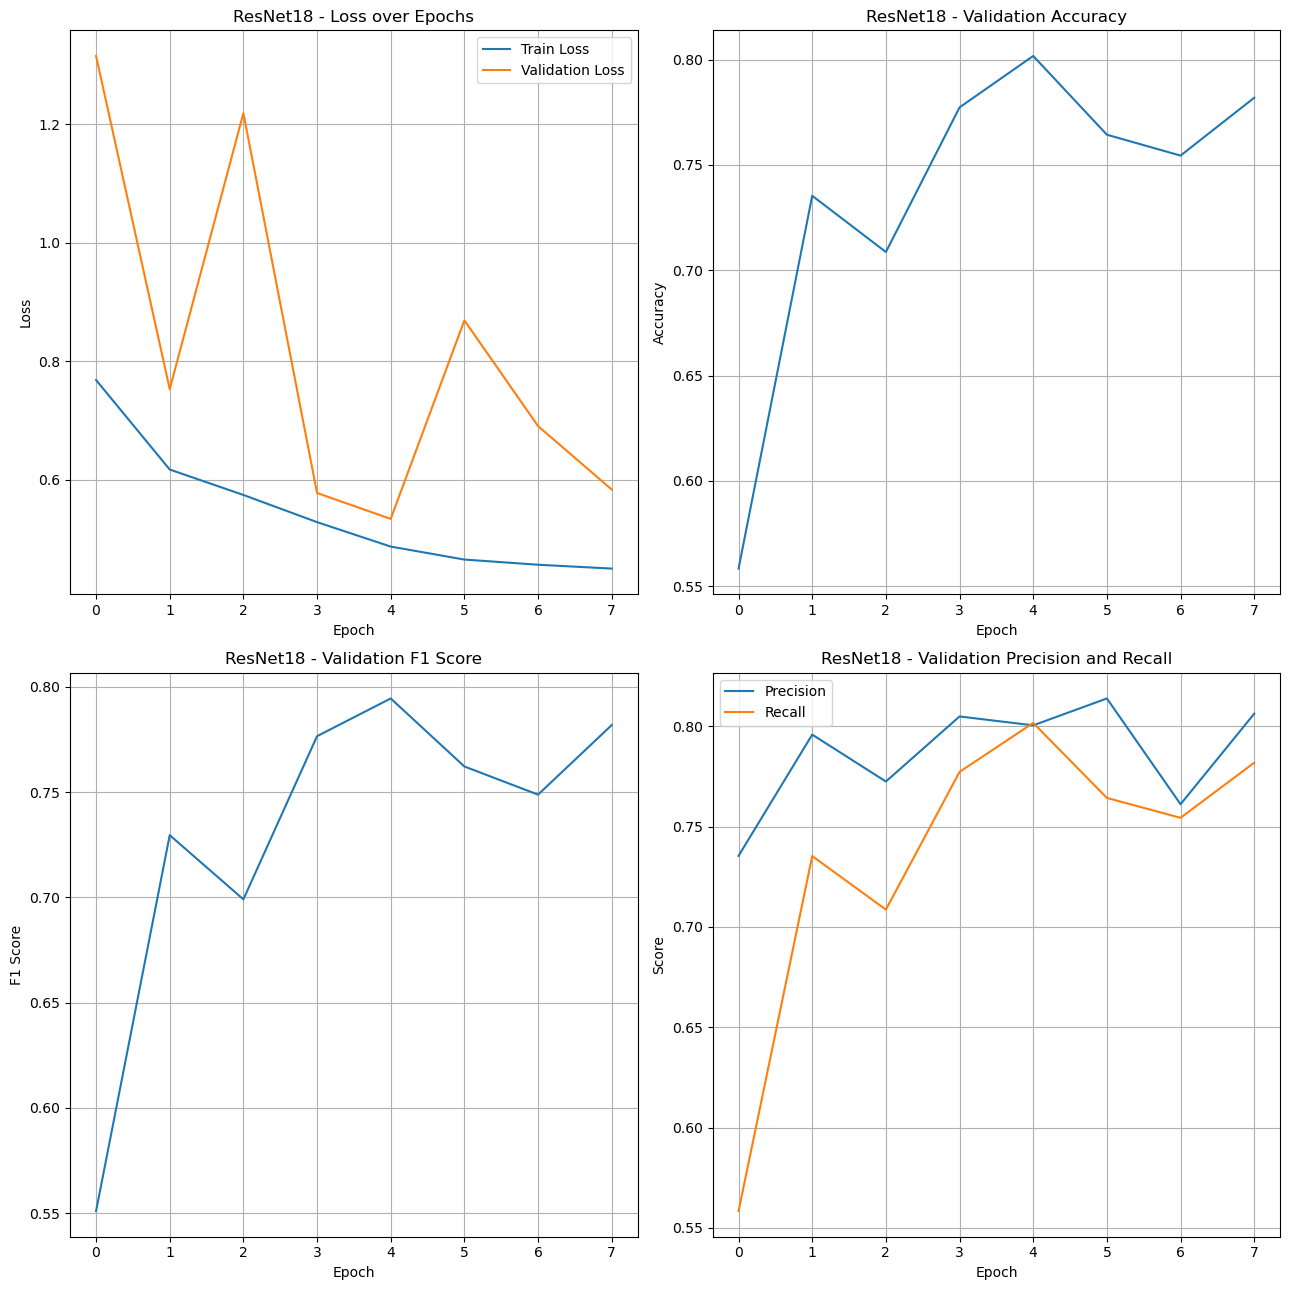

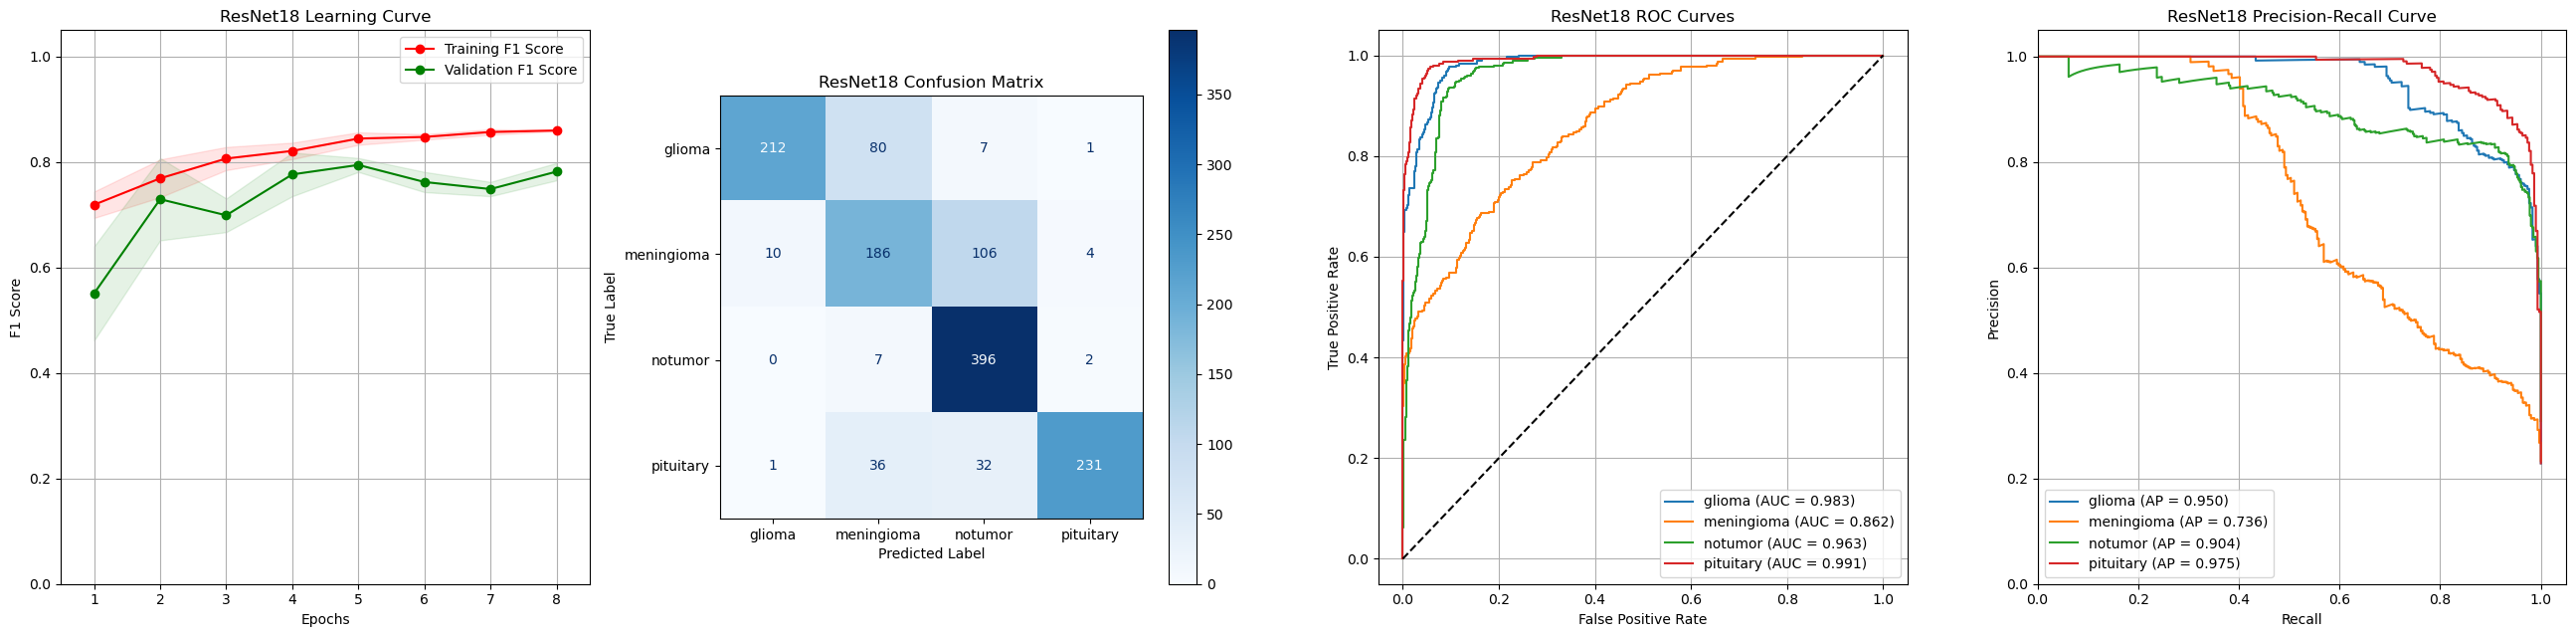

In [7]:
# Create and train ResNet18 model
resnet_model = create_resnet_model(num_classes=4)
resnet_model, resnet_metrics = train_model(
  resnet_model, trainloader, testloader, model_name="ResNet18", num_classes=4
)

In [8]:
def train_model(
  model, trainloader, testloader, model_name="Model", n_epochs=20, patience=3, num_classes=4
):
  # Calculate class weights for balanced loss
  y_train_np = y_train.cpu().numpy()
  class_weights = compute_class_weight(
    "balanced", classes=np.arange(num_classes), y=y_train_np.flatten()
  )
  pos_weight = torch.tensor(class_weights, dtype=torch.float32).to(device)
  print(f"Class weights: {class_weights}")
  print(f"pos_weight: {[pos_weight]}")

  # Loss function and optimizer
  loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
  optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
  )
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, "min", patience=2, factor=0.5
  )

  # Training step function
  train_step = make_train_step(model, optimizer, loss_fn)

  # Initialize tracking variables
  best_loss = float("inf")
  early_stopping_counter = 0
  best_model_weights = None

  train_losses = []
  val_losses = []
  train_metrics_history = []
  val_metrics_history = []

  # Training loop
  for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_loss = 0
    all_train_outputs = []
    all_train_targets = []
    for i, data in tqdm(
      enumerate(trainloader),
      total=len(trainloader),
      desc=f"Epoch {epoch + 1}/{n_epochs}",
    ):
      x_batch, y_batch = data
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      loss = train_step(x_batch, y_batch)
      epoch_loss += loss / len(trainloader)

      with torch.no_grad():
        outputs = model(x_batch)
        all_train_outputs.append(outputs.cpu())
        all_train_targets.append(y_batch.cpu())

    train_losses.append(epoch_loss)
    with torch.no_grad():
      model.eval()  # Set model to evaluation mode
      all_train_outputs = torch.cat(all_train_outputs, dim=0)
      all_train_targets = torch.cat(all_train_targets, dim=0)

      # Convert outputs to probabilities
      train_probs = torch.softmax(all_train_outputs, dim=1).numpy()
      train_preds = np.argmax(train_probs, axis=1)
      train_targets = all_train_targets.numpy()


      # Calculate metrics
      train_metrics = {
        "loss": epoch_loss,
        "accuracy": accuracy_score(train_targets, train_preds),
        "precision": precision_score(train_targets, train_preds, average='weighted', zero_division=0),
        "recall": recall_score(train_targets, train_preds, average='weighted', zero_division=0),
        "f1": f1_score(train_targets, train_preds, average='weighted', zero_division=0),
        "probs": train_probs,
        "predictions": train_preds,
        "targets": train_targets,
      }

      train_metrics_history.append(train_metrics)

    print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {epoch_loss:.4f}")
    print(
      f"Training Accuracy: {train_metrics['accuracy']:.4f}, "
      f"Precision: {train_metrics['precision']:.4f}, Recall: {train_metrics['recall']:.4f}, "
      f"F1 Score: {train_metrics['f1']:.4f}"
    )

    # Validation phase
    val_metrics = evaluate_model(model, testloader, loss_fn, device,num_classes=num_classes)
    val_loss = val_metrics["loss"]
    val_losses.append(val_loss)
    val_metrics_history.append(val_metrics)

    print(
      f"Validation Loss: {val_loss:.4f}, Accuracy: {val_metrics['accuracy']:.4f}, "
      f"Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, "
      f"F1 Score: {val_metrics['f1']:.4f}"
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Check for improvement and early stopping
    if val_loss < best_loss:
      best_loss = val_loss
      best_model_weights = model.state_dict().copy()
      early_stopping_counter = 0
      print(f"New best validation loss: {best_loss:.4f}")
    else:
      early_stopping_counter += 1
      print(f"No improvement for {early_stopping_counter} epochs")

    if early_stopping_counter >= patience:
      print("Early stopping triggered")
      break

  # Load best model weights
  if best_model_weights:
    model.load_state_dict(best_model_weights)
    print(f"Loaded best model with validation loss: {best_loss:.4f}")

  
  # Final evaluation
  final_metrics = evaluate_model(
    model, testloader, loss_fn, device, num_classes=num_classes
  )
  print("\n=== Final Model Evaluation ===")
  print(f"Loss: {final_metrics['loss']:.4f}")
  print(f"Accuracy: {final_metrics['accuracy']:.4f}")
  print(f"Precision: {final_metrics['precision']:.4f}")
  print(f"Recall: {final_metrics['recall']:.4f}")
  print(f"F1 Score: {final_metrics['f1']:.4f}")

  # Plot metrics
  plot_metrics(train_losses, val_losses, val_metrics_history, title_prefix=model_name)

  # Plot confusion matrix
  _, axs = plt.subplots(1, 4, figsize=(26, 6.5))
  plot_learning_curve(
    train_metrics_history,
    val_metrics_history,
    ax=axs[0],
    title=f"{model_name} Learning Curve",
  )
  plot_confusion_matrix(
    final_metrics["targets"],
    final_metrics["predictions"],
    ax=axs[1],
    title=f"{model_name} Confusion Matrix",
    num_classes=num_classes
  )

  # multi-class, per-class ROC
  plot_multiclass_roc(
      final_metrics["targets"],
      final_metrics["probs"],
      ax=axs[2],
      title=f"{model_name} ROC Curves",
      num_classes=num_classes
  )

  plot_multiclass_prcrcl(
    final_metrics["targets"],
    final_metrics["probs"],
    ax=axs[3],
    title=f"{model_name} Precision-Recall Curve",
    num_classes=num_classes
  )

  plt.tight_layout()
  plt.show()

  return model, final_metrics

### **Model Tuning: DenseNet121**
Train and evaluate a fine-tuned DenseNet121 model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]
pos_weight: [tensor([1.0810, 1.0665, 0.8953, 0.9801])]


Epoch 1/20: 100%|██████████| 179/179 [15:13<00:00,  5.11s/it]


Epoch 1/20, Training Loss: 0.6847
Training Accuracy: 0.7638, Precision: 0.7677, Recall: 0.7638, F1 Score: 0.7653
Validation Loss: 0.5743, Accuracy: 0.7475, Precision: 0.7614, Recall: 0.7475, F1 Score: 0.7441
New best validation loss: 0.5743


Epoch 2/20: 100%|██████████| 179/179 [15:17<00:00,  5.12s/it]


Epoch 2/20, Training Loss: 0.5271
Training Accuracy: 0.8183, Precision: 0.8232, Recall: 0.8183, F1 Score: 0.8199
Validation Loss: 0.6303, Accuracy: 0.7681, Precision: 0.7813, Recall: 0.7681, F1 Score: 0.7599
No improvement for 1 epochs


Epoch 3/20: 100%|██████████| 179/179 [15:30<00:00,  5.20s/it]


Epoch 3/20, Training Loss: 0.4738
Training Accuracy: 0.8393, Precision: 0.8426, Recall: 0.8393, F1 Score: 0.8402
Validation Loss: 0.6061, Accuracy: 0.7368, Precision: 0.7869, Recall: 0.7368, F1 Score: 0.7412
No improvement for 2 epochs


Epoch 4/20: 100%|██████████| 179/179 [15:27<00:00,  5.18s/it]


Epoch 4/20, Training Loss: 0.4413
Training Accuracy: 0.8519, Precision: 0.8552, Recall: 0.8519, F1 Score: 0.8527
Validation Loss: 0.5750, Accuracy: 0.7666, Precision: 0.7918, Recall: 0.7666, F1 Score: 0.7614
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.5743

=== Final Model Evaluation ===
Loss: 0.5750
Accuracy: 0.7666
Precision: 0.7918
Recall: 0.7666
F1 Score: 0.7614


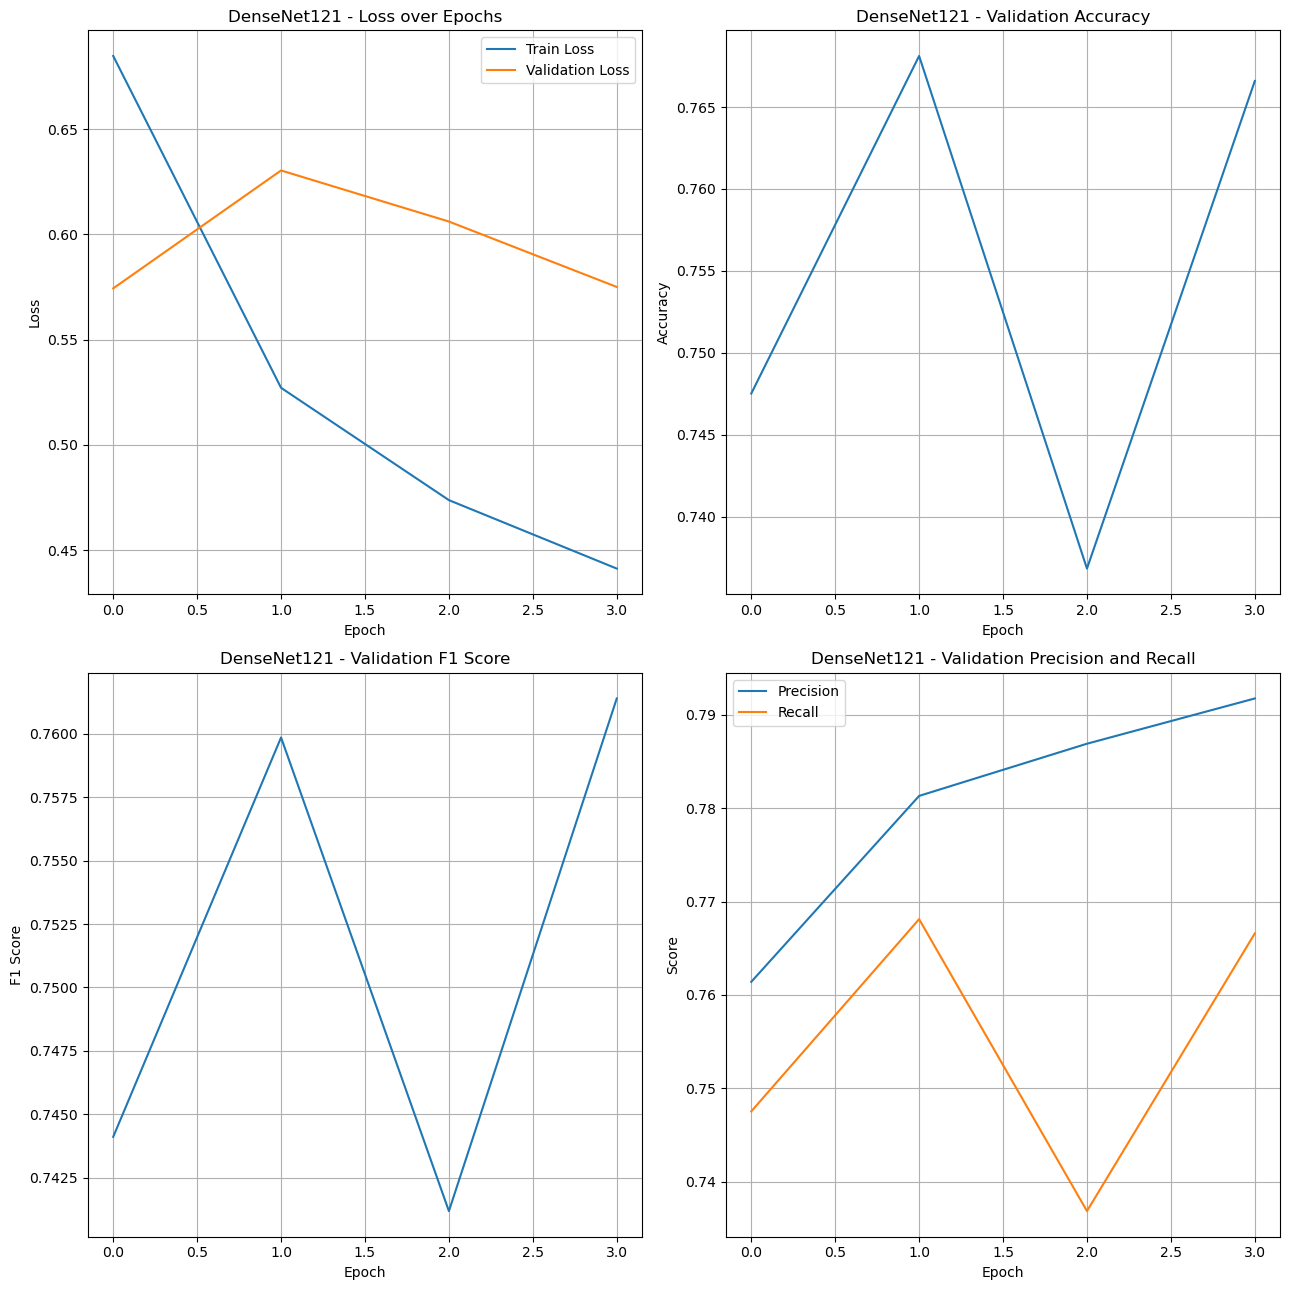

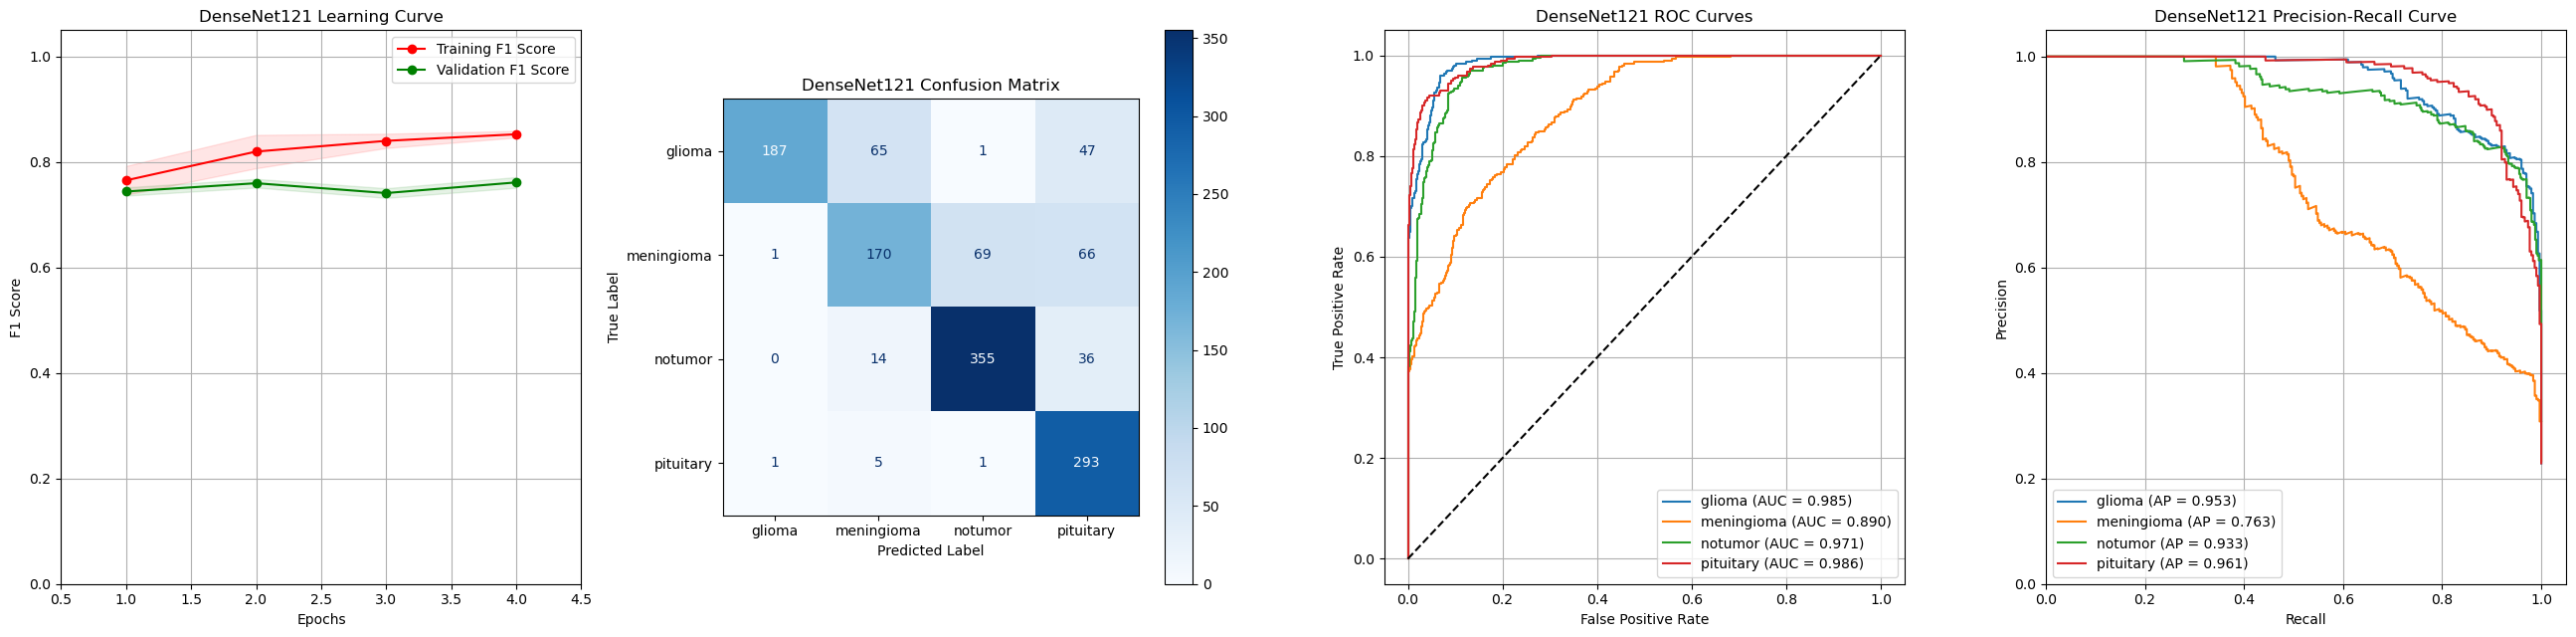

In [9]:
# Create and train DenseNet121 model
densenet_model = create_densenet_model(num_classes=4)
densenet_model, densenet_metrics = train_model(
  densenet_model, trainloader, testloader, model_name="DenseNet121", num_classes=4
)

### **Model Tuning: EfficientNet-B0**
Train and evaluate a fine-tuned EfficientNet-B0 model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]
pos_weight: [tensor([1.0810, 1.0665, 0.8953, 0.9801])]


Epoch 1/20: 100%|██████████| 179/179 [22:49<00:00,  7.65s/it]   


Epoch 1/20, Training Loss: 0.6862
Training Accuracy: 0.7535, Precision: 0.7544, Recall: 0.7535, F1 Score: 0.7526
Validation Loss: 0.8449, Accuracy: 0.7162, Precision: 0.7697, Recall: 0.7162, F1 Score: 0.7322
New best validation loss: 0.8449


Epoch 2/20: 100%|██████████| 179/179 [11:13<00:00,  3.76s/it]


Epoch 2/20, Training Loss: 0.5327
Training Accuracy: 0.8092, Precision: 0.8131, Recall: 0.8092, F1 Score: 0.8100
Validation Loss: 0.5745, Accuracy: 0.7803, Precision: 0.8008, Recall: 0.7803, F1 Score: 0.7808
New best validation loss: 0.5745


...

Epoch 14/20, Training Loss: 0.3022
Training Accuracy: 0.8993, Precision: 0.9018, Recall: 0.8993, F1 Score: 0.9000
Validation Loss: 0.3730, Accuracy: 0.8482, Precision: 0.8578, Recall: 0.8482, F1 Score: 0.8503
No improvement for 1 epochs


Epoch 15/20: 100%|██████████| 179/179 [11:16<00:00,  3.78s/it]


Epoch 15/20, Training Loss: 0.3051
Training Accuracy: 0.8972, Precision: 0.8989, Recall: 0.8972, F1 Score: 0.8976
Validation Loss: 0.3414, Accuracy: 0.8680, Precision: 0.8681, Recall: 0.8680, F1 Score: 0.8641
No improvement for 2 epochs


Epoch 16/20: 100%|██████████| 179/179 [11:13<00:00,  3.76s/it]


Epoch 16/20, Training Loss: 0.2743
Training Accuracy: 0.9009, Precision: 0.9029, Recall: 0.9009, F1 Score: 0.9015
Validation Loss: 0.3141, Accuracy: 0.8558, Precision: 0.8739, Recall: 0.8558, F1 Score: 0.8579
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.2999

=== Final Model Evaluation ===
Loss: 0.3141
Accuracy: 0.8558
Precision: 0.8739
Recall: 0.8558
F1 Score: 0.8579


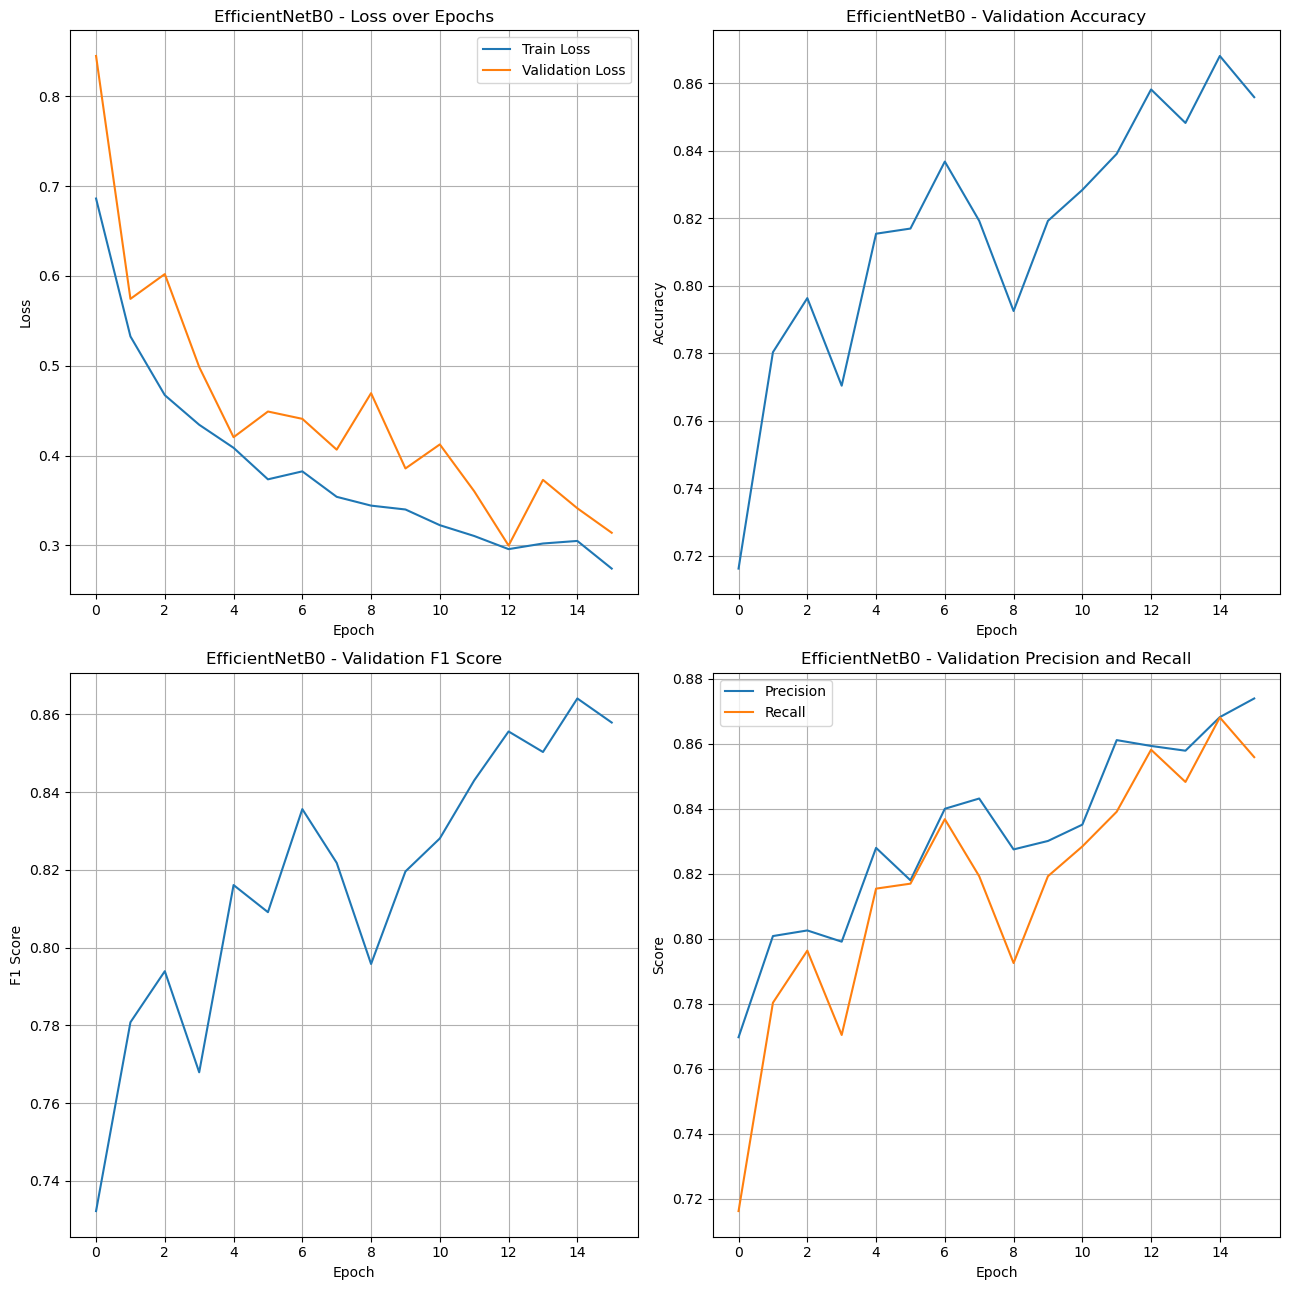

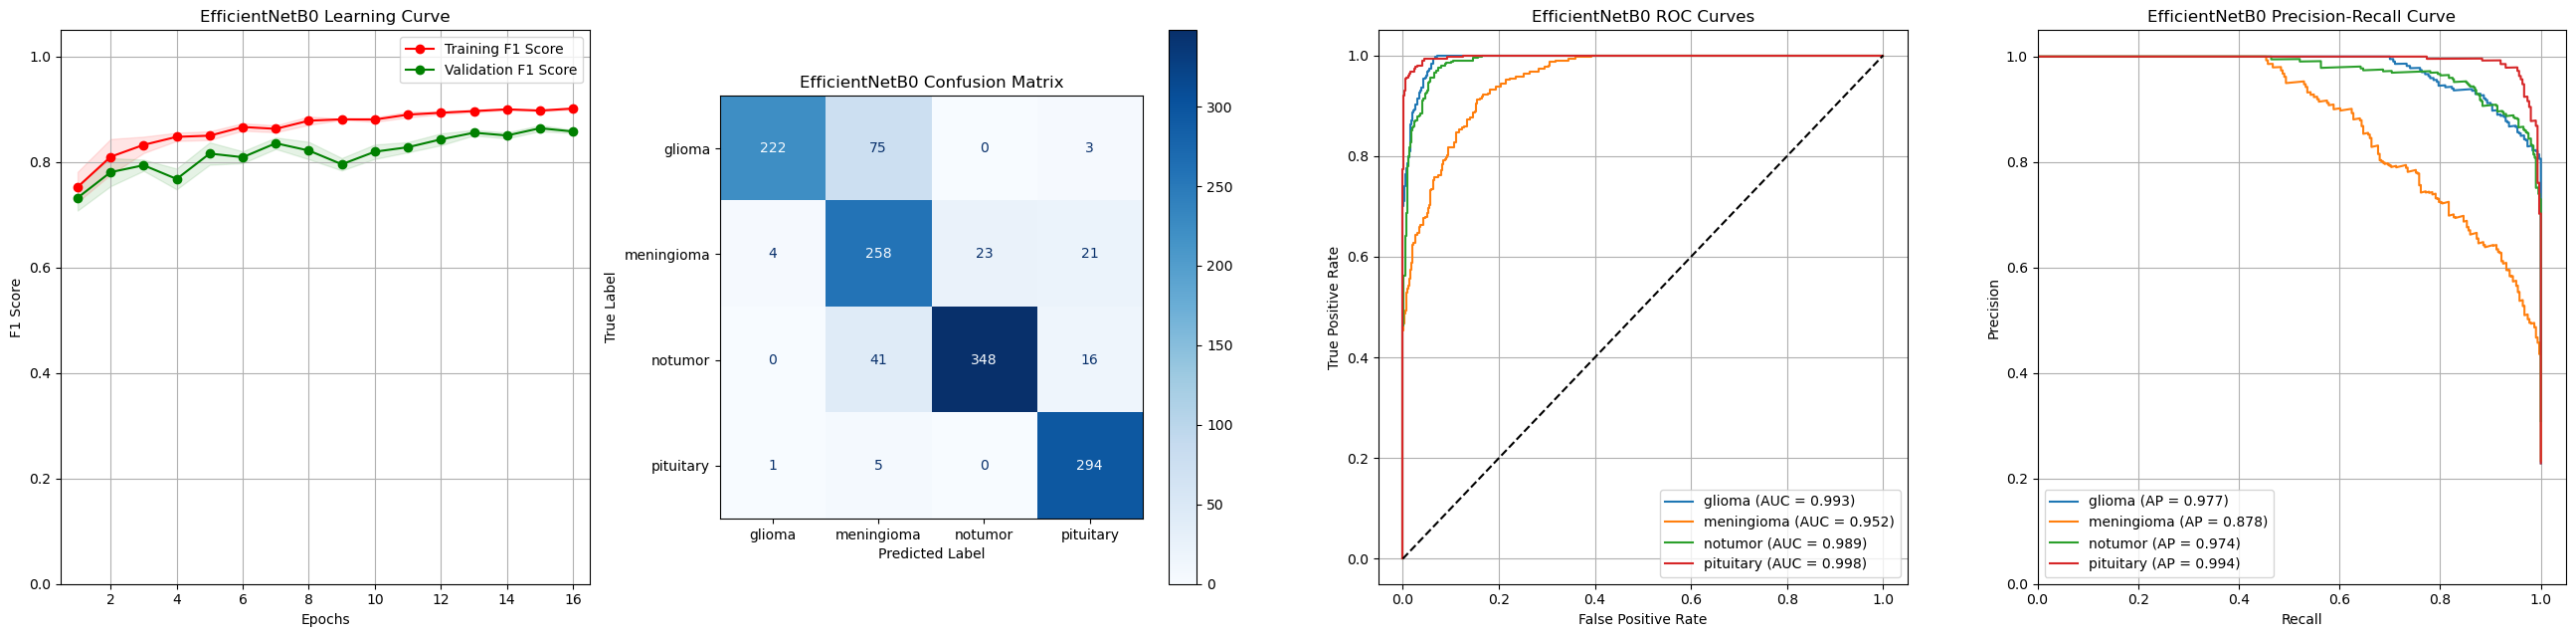

In [10]:
# Create and train EfficientNet model
efficientnet_model = create_efficientnet_model(num_classes=4)
efficientnet_model, efficientnet_metrics = train_model(
  efficientnet_model, trainloader, testloader, model_name="EfficientNetB0", num_classes=4
)

### **Model Tuning: ViT-B/16**
Train and evaluate a fine-tuned ViT-B/16 model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]
pos_weight: [tensor([1.0810, 1.0665, 0.8953, 0.9801])]


Epoch 1/20: 100%|██████████| 179/179 [09:16<00:00,  3.11s/it]


Epoch 1/20, Training Loss: 0.8985
Training Accuracy: 0.6063, Precision: 0.6258, Recall: 0.6063, F1 Score: 0.5974
Validation Loss: 0.9105, Accuracy: 0.5843, Precision: 0.7079, Recall: 0.5843, F1 Score: 0.6019
New best validation loss: 0.9105


Epoch 2/20: 100%|██████████| 179/179 [09:39<00:00,  3.24s/it]


Epoch 2/20, Training Loss: 0.8009
Training Accuracy: 0.6506, Precision: 0.6850, Recall: 0.6506, F1 Score: 0.6478
Validation Loss: 0.8494, Accuracy: 0.7002, Precision: 0.7495, Recall: 0.7002, F1 Score: 0.6922
New best validation loss: 0.8494


...

Epoch 8/20, Training Loss: 0.7270
Training Accuracy: 0.6805, Precision: 0.7005, Recall: 0.6805, F1 Score: 0.6812
Validation Loss: 0.7739, Accuracy: 0.7292, Precision: 0.7856, Recall: 0.7292, F1 Score: 0.7235
No improvement for 1 epochs


Epoch 9/20: 100%|██████████| 179/179 [09:32<00:00,  3.20s/it]


Epoch 9/20, Training Loss: 0.7096
Training Accuracy: 0.6889, Precision: 0.7032, Recall: 0.6889, F1 Score: 0.6893
Validation Loss: 0.7638, Accuracy: 0.7246, Precision: 0.7821, Recall: 0.7246, F1 Score: 0.7201
No improvement for 2 epochs


Epoch 10/20: 100%|██████████| 179/179 [09:28<00:00,  3.17s/it]


Epoch 10/20, Training Loss: 0.7105
Training Accuracy: 0.6856, Precision: 0.7025, Recall: 0.6856, F1 Score: 0.6878
Validation Loss: 0.7430, Accuracy: 0.7254, Precision: 0.7533, Recall: 0.7254, F1 Score: 0.7278
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.7382

=== Final Model Evaluation ===
Loss: 0.7430
Accuracy: 0.7254
Precision: 0.7533
Recall: 0.7254
F1 Score: 0.7278


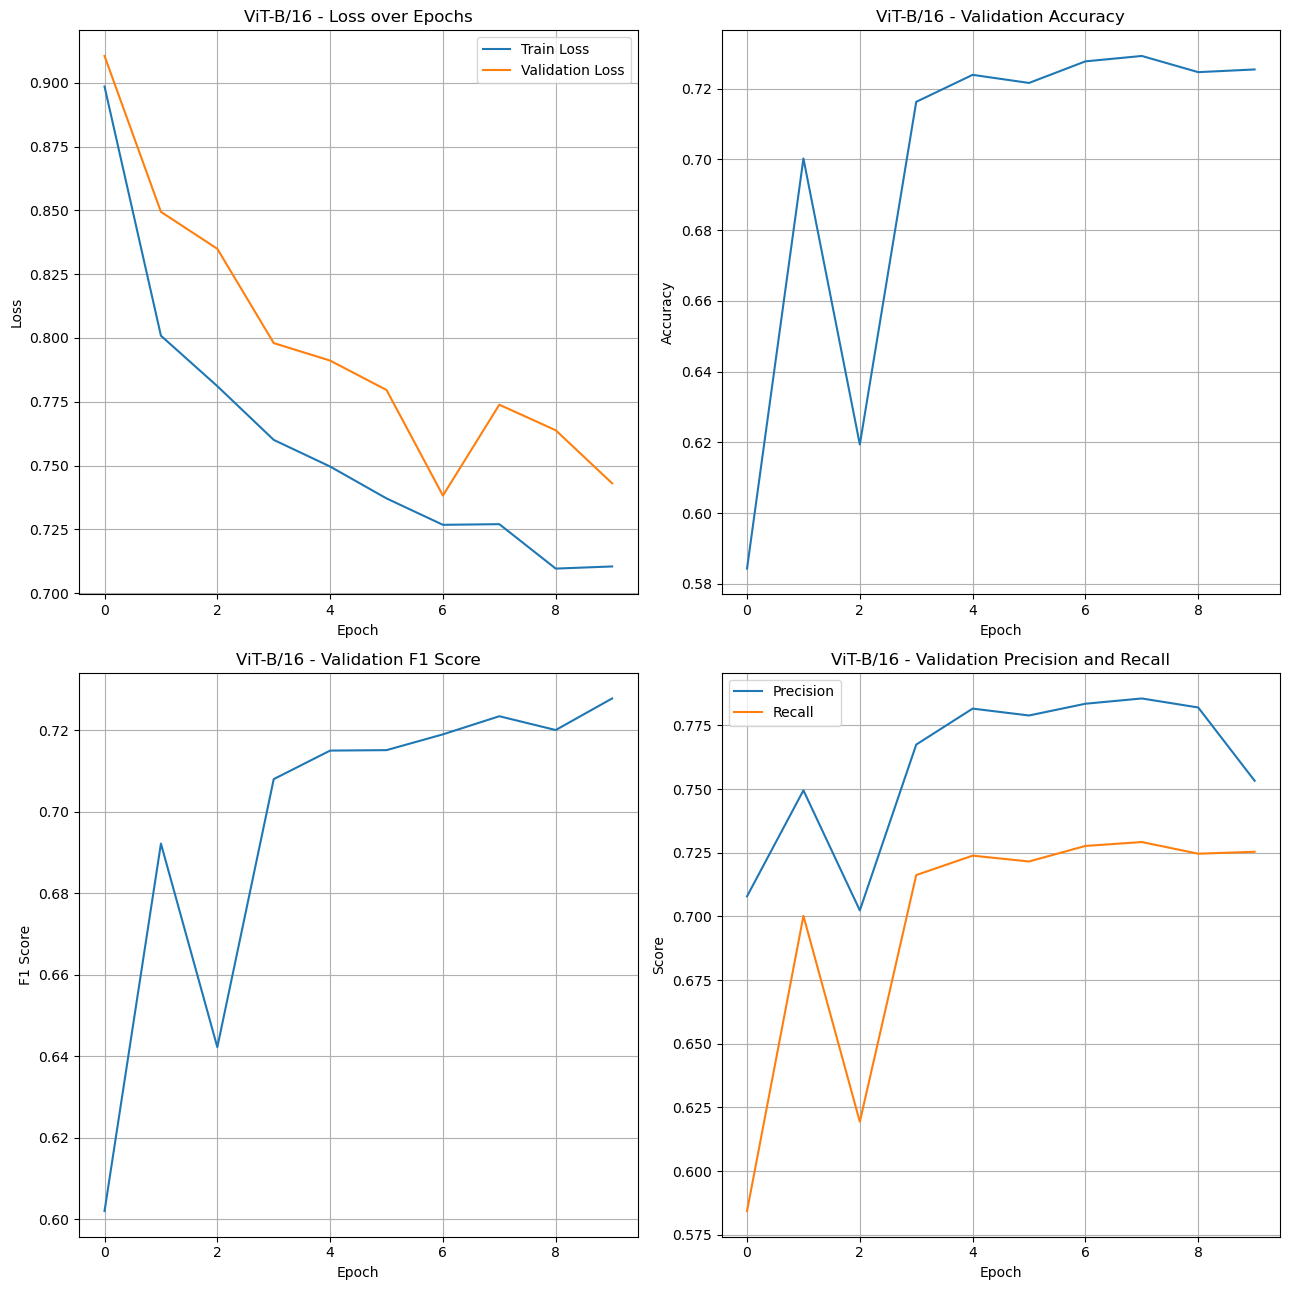

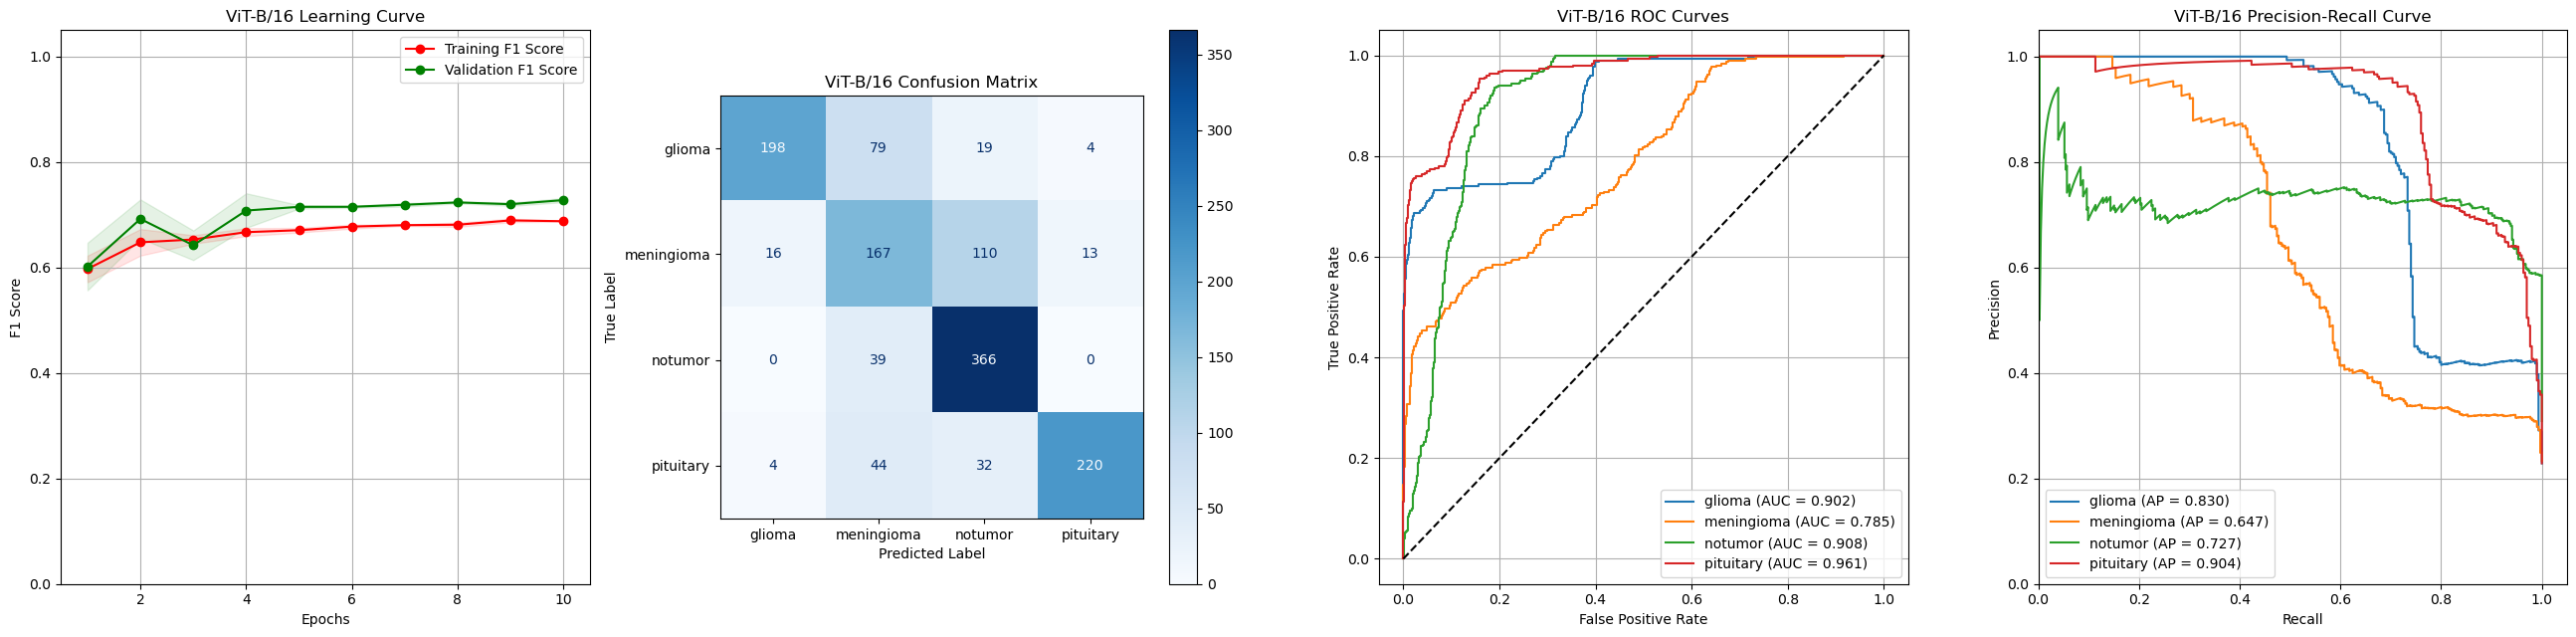

In [11]:
vit_model = create_vit_model(num_classes=4)
vit_model, vit_metrics = train_model(
  vit_model, trainloader, testloader, model_name="ViT-B/16", num_classes=4
)

### **Model Tuning: Swin-T**
Train and evaluate a fine-tuned Swin-T model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]
pos_weight: [tensor([1.0810, 1.0665, 0.8953, 0.9801])]


Epoch 1/20: 100%|██████████| 179/179 [05:41<00:00,  1.91s/it]


Epoch 1/20, Training Loss: 0.9154
Training Accuracy: 0.6091, Precision: 0.6399, Recall: 0.6091, F1 Score: 0.6029
Validation Loss: 0.8318, Accuracy: 0.7201, Precision: 0.7793, Recall: 0.7201, F1 Score: 0.7104
New best validation loss: 0.8318


Epoch 2/20: 100%|██████████| 179/179 [05:43<00:00,  1.92s/it]


Epoch 2/20, Training Loss: 0.8105
Training Accuracy: 0.6415, Precision: 0.6826, Recall: 0.6415, F1 Score: 0.6397
Validation Loss: 0.7796, Accuracy: 0.6293, Precision: 0.7176, Recall: 0.6293, F1 Score: 0.6491
New best validation loss: 0.7796


...

Epoch 6/20, Training Loss: 0.7432
Training Accuracy: 0.6702, Precision: 0.7024, Recall: 0.6702, F1 Score: 0.6684
Validation Loss: 0.7302, Accuracy: 0.6186, Precision: 0.7485, Recall: 0.6186, F1 Score: 0.6297
No improvement for 1 epochs


Epoch 7/20: 100%|██████████| 179/179 [05:41<00:00,  1.91s/it]


Epoch 7/20, Training Loss: 0.7309
Training Accuracy: 0.6710, Precision: 0.7008, Recall: 0.6710, F1 Score: 0.6711
Validation Loss: 0.7351, Accuracy: 0.7269, Precision: 0.7893, Recall: 0.7269, F1 Score: 0.7222
No improvement for 2 epochs


Epoch 8/20: 100%|██████████| 179/179 [05:43<00:00,  1.92s/it]


Epoch 8/20, Training Loss: 0.7182
Training Accuracy: 0.6803, Precision: 0.7145, Recall: 0.6803, F1 Score: 0.6816
Validation Loss: 0.7471, Accuracy: 0.6644, Precision: 0.7528, Recall: 0.6644, F1 Score: 0.6868
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.7079

=== Final Model Evaluation ===
Loss: 0.7471
Accuracy: 0.6644
Precision: 0.7528
Recall: 0.6644
F1 Score: 0.6868


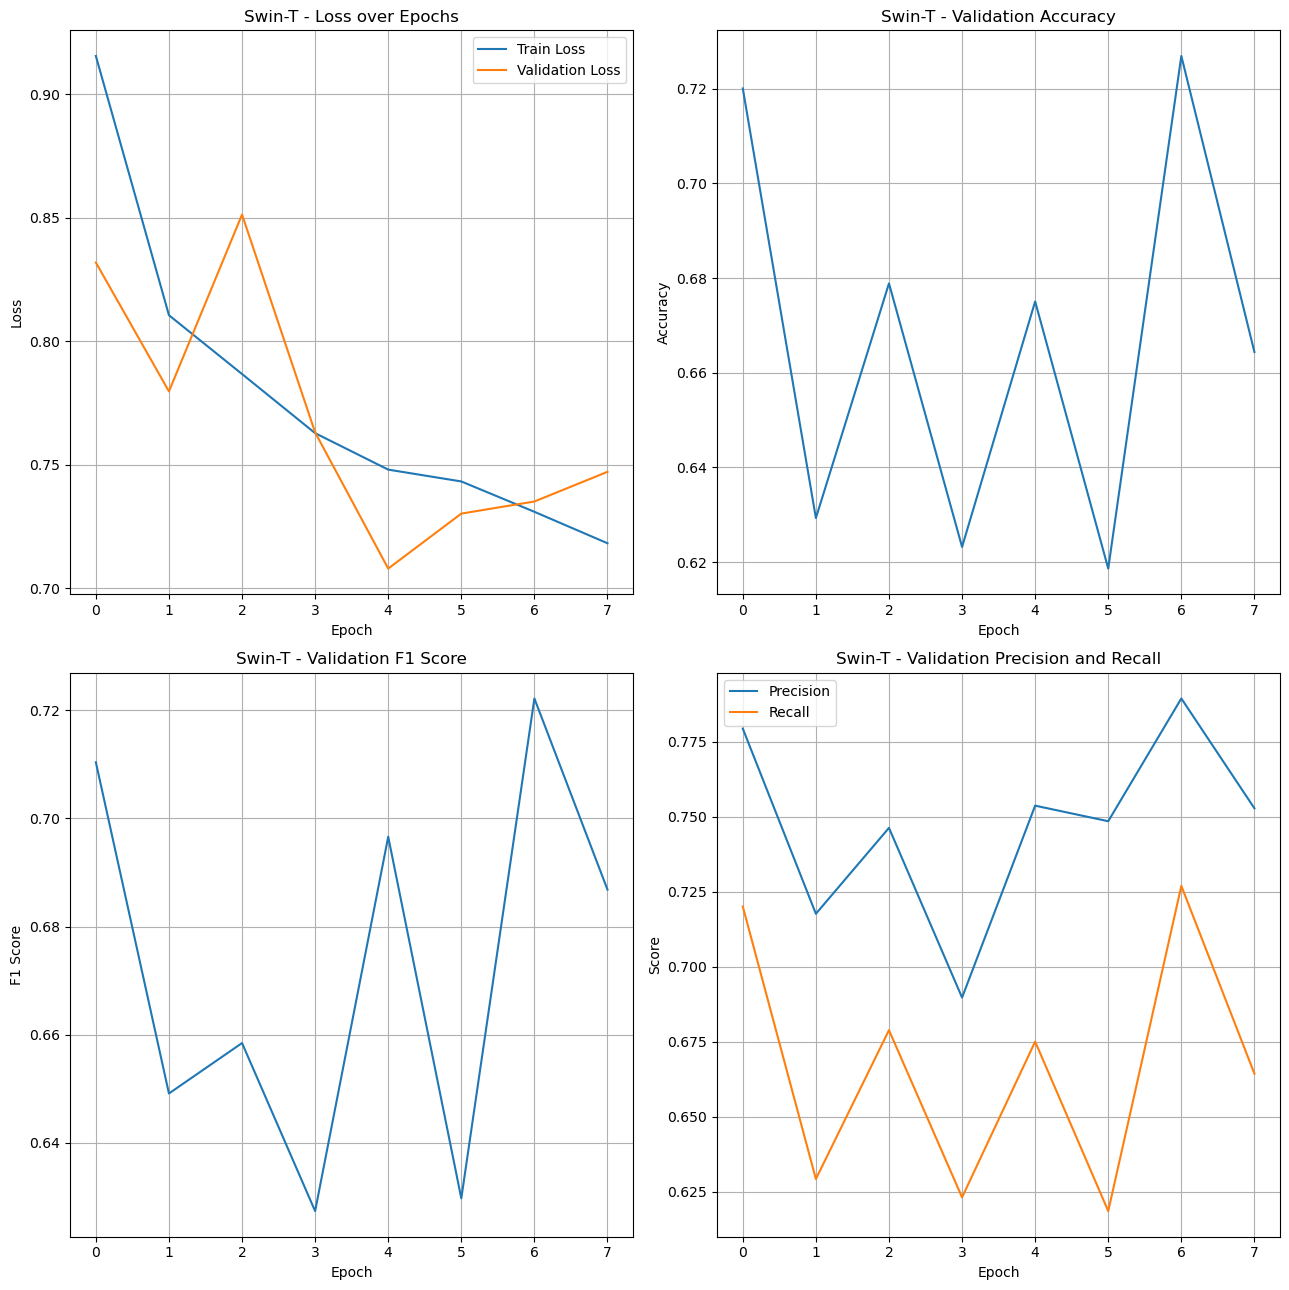

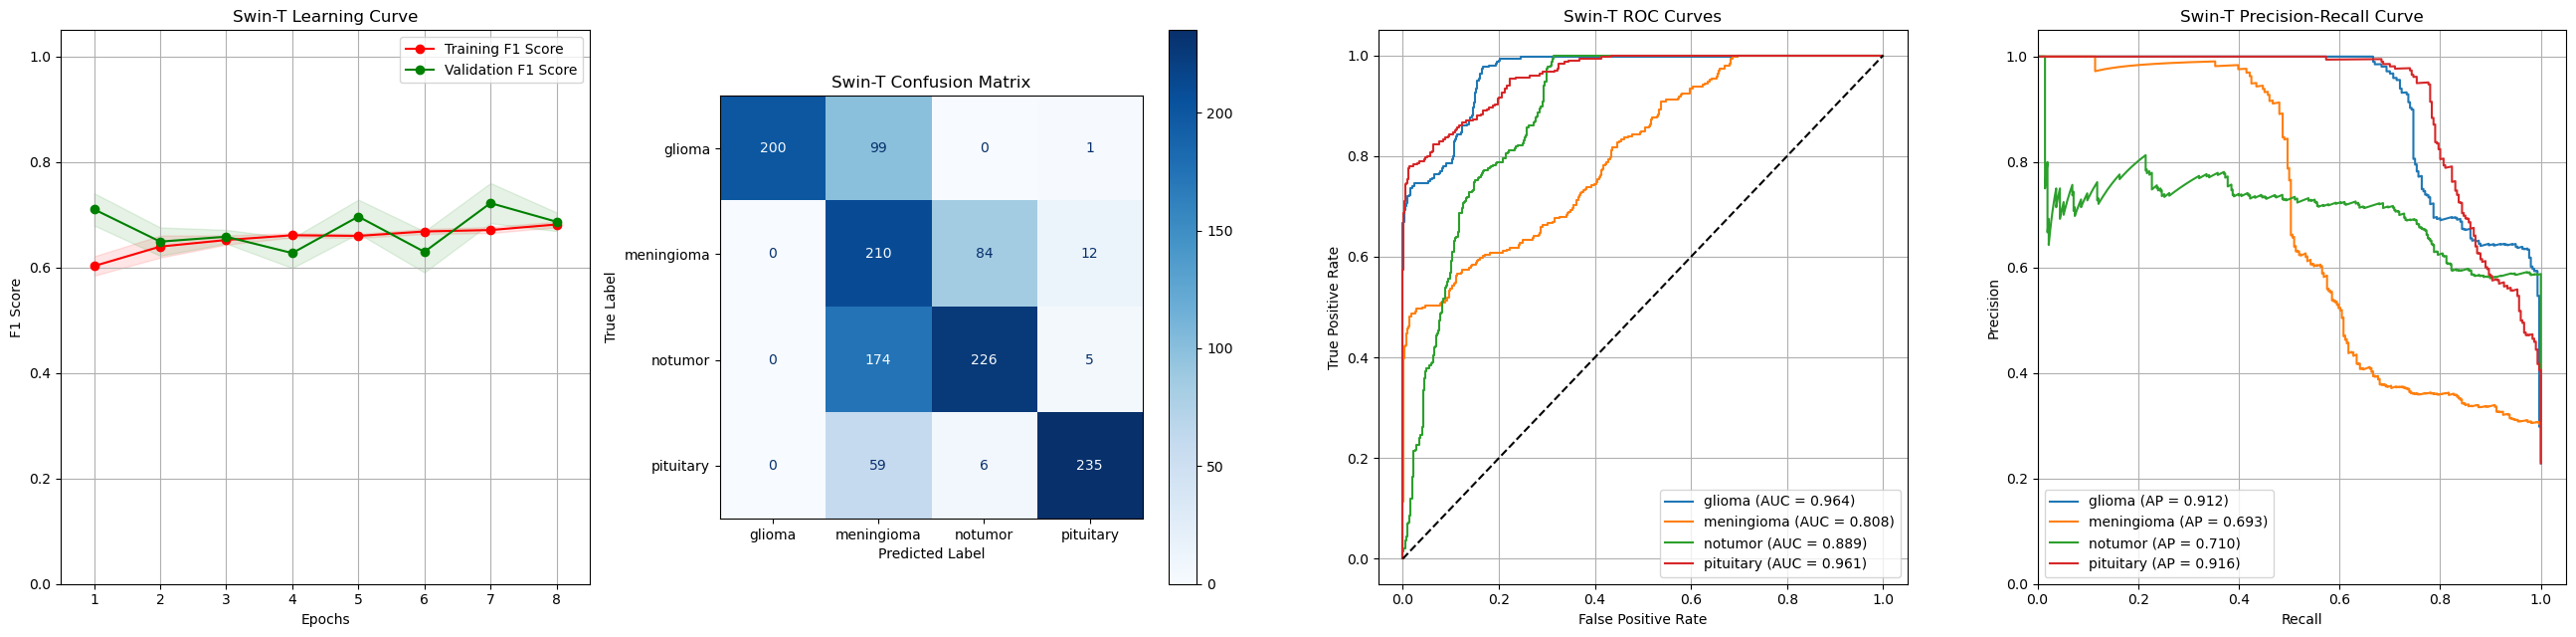

In [12]:
swin_model = create_swin_model(num_classes=4)
swin_model, swin_metrics = train_model(
  swin_model, trainloader, testloader, model_name="Swin-T", num_classes=4
)

### **Model Tuning: ConvNeXt-T**
Train and evaluate a fine-tuned ConvNeXt-T model.

Class weights: [1.08099924 1.06646751 0.89529781 0.98009609]
pos_weight: [tensor([1.0810, 1.0665, 0.8953, 0.9801])]


Epoch 1/20: 100%|██████████| 179/179 [09:18<00:00,  3.12s/it]


Epoch 1/20, Training Loss: 0.7151
Training Accuracy: 0.7145, Precision: 0.7188, Recall: 0.7145, F1 Score: 0.7162
Validation Loss: 0.6573, Accuracy: 0.7285, Precision: 0.7590, Recall: 0.7285, F1 Score: 0.7338
New best validation loss: 0.6573


Epoch 2/20: 100%|██████████| 179/179 [09:22<00:00,  3.14s/it]


Epoch 2/20, Training Loss: 0.5913
Training Accuracy: 0.7682, Precision: 0.7780, Recall: 0.7682, F1 Score: 0.7719
Validation Loss: 0.6387, Accuracy: 0.7117, Precision: 0.7484, Recall: 0.7117, F1 Score: 0.7234
New best validation loss: 0.6387


...

Epoch 15/20, Training Loss: 0.3993
Training Accuracy: 0.8582, Precision: 0.8651, Recall: 0.8582, F1 Score: 0.8604
Validation Loss: 0.4380, Accuracy: 0.7979, Precision: 0.8115, Recall: 0.7979, F1 Score: 0.8007
No improvement for 1 epochs


Epoch 16/20: 100%|██████████| 179/179 [09:21<00:00,  3.14s/it]


Epoch 16/20, Training Loss: 0.3963
Training Accuracy: 0.8533, Precision: 0.8594, Recall: 0.8533, F1 Score: 0.8554
Validation Loss: 0.4987, Accuracy: 0.7864, Precision: 0.8190, Recall: 0.7864, F1 Score: 0.7947
No improvement for 2 epochs


Epoch 17/20: 100%|██████████| 179/179 [09:21<00:00,  3.14s/it]


Epoch 17/20, Training Loss: 0.4016
Training Accuracy: 0.8528, Precision: 0.8597, Recall: 0.8528, F1 Score: 0.8550
Validation Loss: 0.4918, Accuracy: 0.7902, Precision: 0.8156, Recall: 0.7902, F1 Score: 0.7958
No improvement for 3 epochs
Early stopping triggered
Loaded best model with validation loss: 0.4162

=== Final Model Evaluation ===
Loss: 0.4918
Accuracy: 0.7902
Precision: 0.8156
Recall: 0.7902
F1 Score: 0.7958


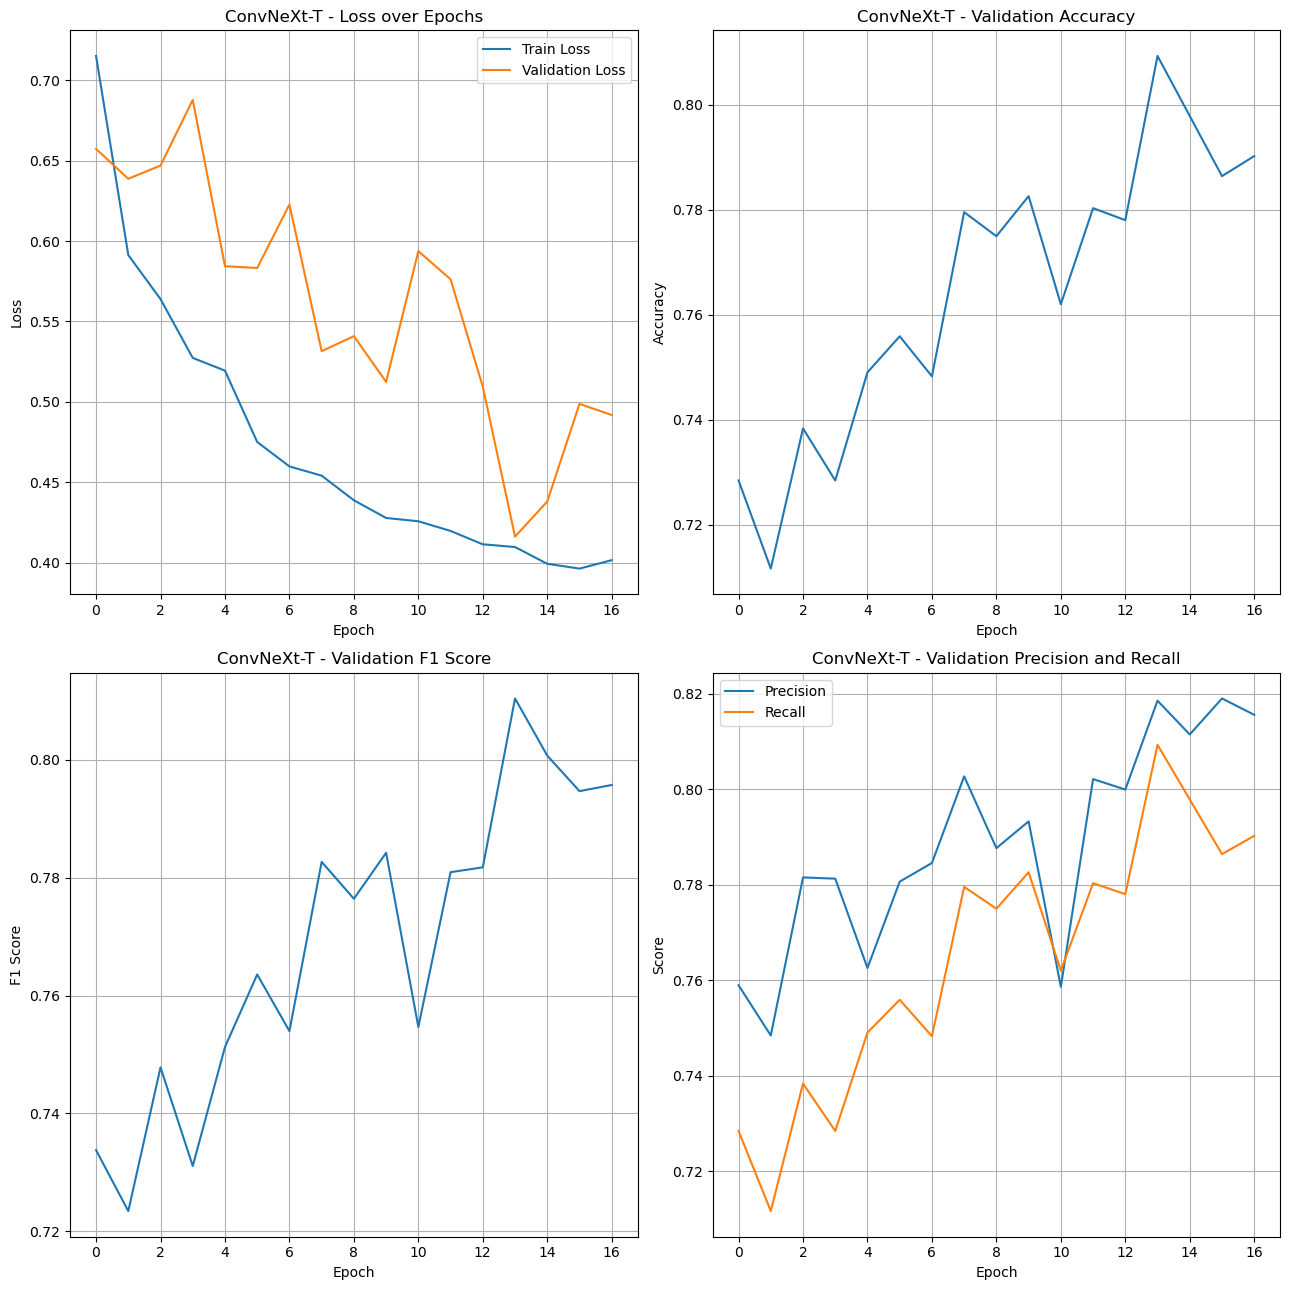

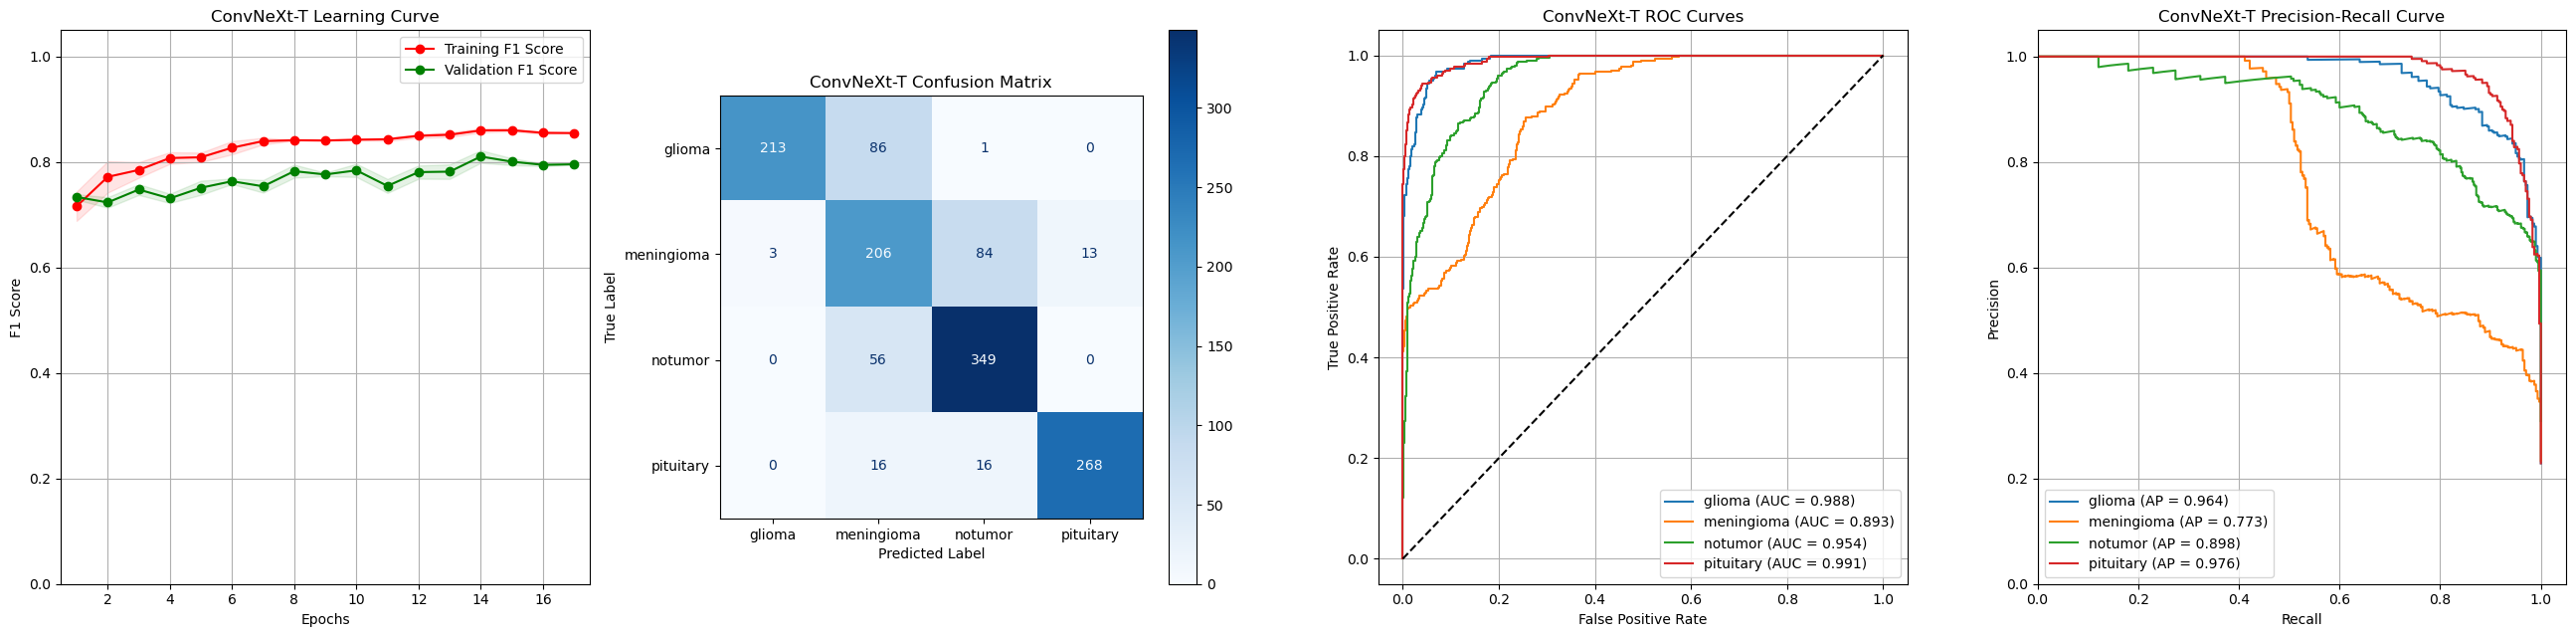

In [13]:
convnext_model = create_convnext_model(num_classes=4)
convnext_model, convnext_metrics = train_model(
  convnext_model, trainloader, testloader, model_name="ConvNeXt-T", num_classes=4
)

### **Model Comparison**
Compare the performance of all models.

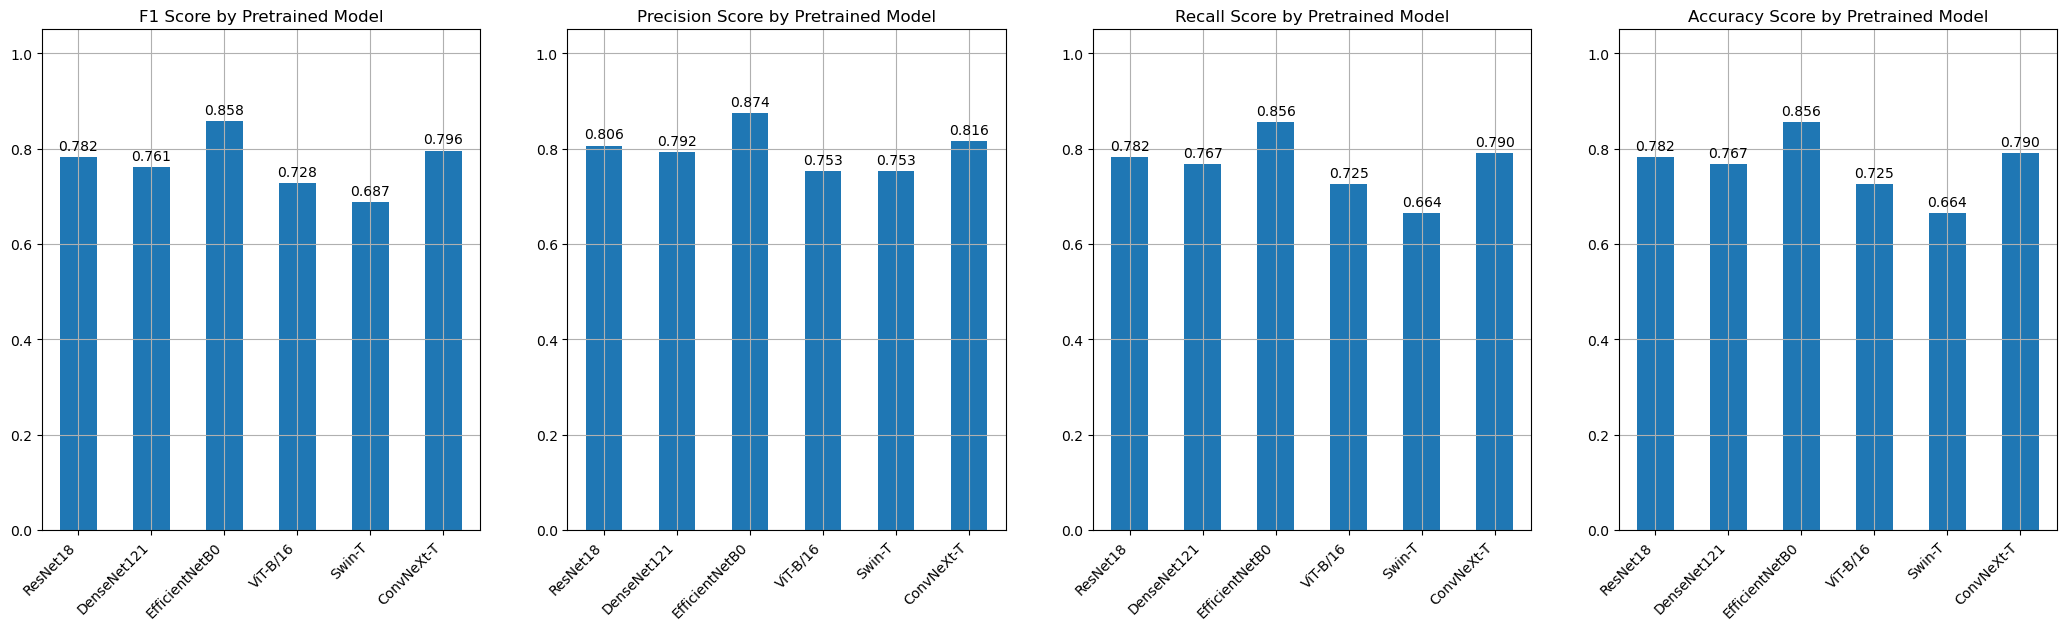

In [14]:
# Compile results for comparison
model_names = [
  "ResNet18",
  "DenseNet121",
  "EfficientNetB0",
  "ViT-B/16",
  "Swin-T",
  "ConvNeXt-T",
]
metrics = [
  resnet_metrics,
  densenet_metrics,
  efficientnet_metrics,
  vit_metrics,
  swin_metrics,
  convnext_metrics,
]

# Create comparison dataframe
comparison_df = pd.DataFrame(
  {
    "F1": [m["f1"] for m in metrics],
    "Precision": [m["precision"] for m in metrics],
    "Recall": [m["recall"] for m in metrics],
    "Accuracy": [m["accuracy"] for m in metrics],
  },
  index=model_names,
)

_, axs = plt.subplots(1, 4, figsize=(26, 6.5))
for index, col in enumerate(comparison_df.columns):
  ax = axs[index]
  bars = comparison_df.plot.bar(
    y=col,
    use_index=True,
    ylim=[0.0, 1.05],
    legend=False,
    grid=True,
    title=f"{col} Score by Pretrained Model",
    ax=ax,
  )
  ax.bar_label(bars.containers[0], fmt="%.3f", padding=3)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

### **Feature Visualization with Class Activation Maps**
Visualize what the model is focusing on using Grad-CAM.

In [18]:
import numpy as np
import torch
import cv2
from matplotlib import pyplot as plt


def visualize_gradcam(model, target_layer, image, label, model_name):
  # Set the model to evaluation mode
  model.eval()

  # Ensure we're working with a batch
  if len(image.shape) == 3:
    image = image.unsqueeze(0)

  # Check if the model expects 3 channels but image has 1 channel
  # Create a 3-channel version if needed
  if image.shape[1] == 1 and model_name in [
    "ResNet18",
    "DenseNet121",
    "EfficientNetB0",
    "ConvNeXt-T",
  ]:
    image_input = image.repeat(1, 3, 1, 1).clone().detach().requires_grad_(True)
  else:
    image_input = image.clone().detach().requires_grad_(True)

  # Store activations and gradients
  activations = []

  # Forward hook for the target layer
  def get_activations(module, input, output):
    activations.append(output.detach())

  # Register the hook
  handle = target_layer.register_forward_hook(get_activations)

  # Forward pass
  output = model(image_input)
  pred_class = torch.argmax(output).item()
  pred_score = torch.softmax(output, dim=1)[0, pred_class].item()

  # Clear gradients
  model.zero_grad()

  # Backward pass for the predicted class
  one_hot = torch.zeros_like(output)
  one_hot[0, pred_class] = 1
  output.backward(gradient=one_hot)

  # Get the gradients coming into the target layer
  gradients = image_input.grad

  # Get the activations of the last convolutional layer
  if not activations:
    handle.remove()
    raise ValueError(
      f"No activations captured for {model_name}. Check the target layer."
    )

  target_activations = activations[0]

  # Calculate the average gradient for each feature map channel
  weights = torch.mean(gradients, dim=[0, 2, 3])

  # Create the class activation map
  cam = torch.zeros(target_activations.size()[2:], device=target_activations.device)

  # Multiply each weight with its corresponding feature map
  for i, w in enumerate(weights):
    cam += w * target_activations[0, i, :, :]

  # Apply ReLU to focus on features that have a positive influence
  cam = torch.relu(cam)

  # Normalize the CAM
  if torch.max(cam) > 0:
    cam = cam / torch.max(cam)

  # Convert to numpy for visualization
  cam_np = cam.cpu().detach().numpy()

  # Original image for display
  original_img = image.squeeze(0).cpu().detach().numpy()

  # Handle different image formats
  if original_img.shape[0] == 1:  # Single channel
    original_img = original_img.squeeze(0)  # Remove channel dimension
    img_for_display = np.repeat(
      original_img[:, :, np.newaxis], 3, axis=2
    )  # Convert to 3 channels for display
  elif original_img.shape[0] == 3:  # RGB
    img_for_display = np.transpose(original_img, (1, 2, 0))  # CHW to HWC
  else:
    raise ValueError(f"Unexpected number of channels: {original_img.shape[0]}")

  # Normalize for visualization
  img_for_display = (img_for_display - np.min(img_for_display)) / (
    np.max(img_for_display) - np.min(img_for_display)
  )

  # Resize CAM to match the input image size
  h, w = original_img.shape[-2], original_img.shape[-1]
  cam_resized = cv2.resize(cam_np, (w, h))

  # Apply colormap
  heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
  heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

  # Create the overlay
  alpha = 0.4
  overlay = (1 - alpha) * img_for_display + alpha * heatmap

  # Create the visualization
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 3, 1)
  plt.imshow(img_for_display, cmap="gray" if original_img.shape[0] == 1 else None)
  plt.title("Original Image")
  plt.axis("off")

  plt.subplot(1, 3, 2)
  plt.imshow(cam_resized, cmap="jet")
  plt.title("Grad-CAM")
  plt.axis("off")

  plt.subplot(1, 3, 3)
  plt.imshow(overlay)
  plt.title("Overlay")
  plt.axis("off")

  # Add overall title with prediction info
  class_name = "Normal" if pred_class == 0 else "Pneumonia"
  actual_class = "Normal" if label.item() == 0 else "Pneumonia"
  plt.suptitle(
    f"{model_name}: Actual: {actual_class}, Predicted: {class_name} ({pred_score:.2f})"
  )

  plt.tight_layout()
  plt.show()

  # Clean up
  handle.remove()

=== Visualization for Normal Case ===


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


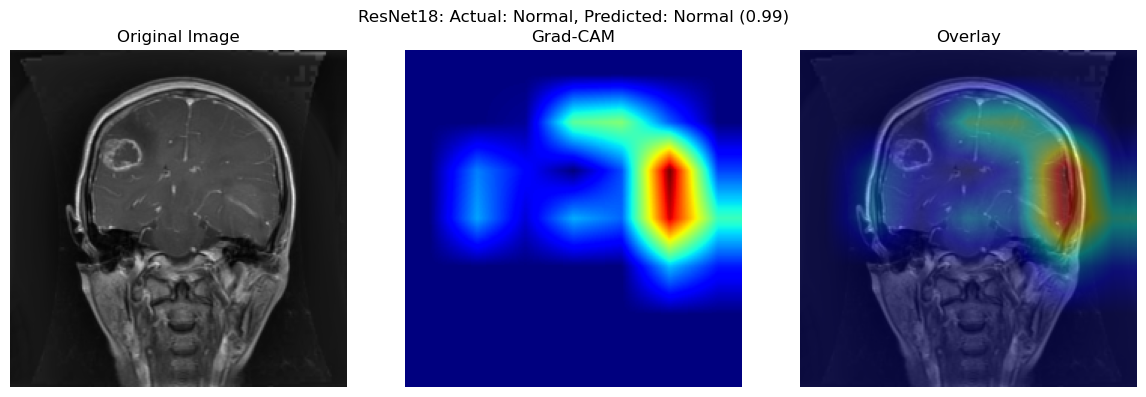

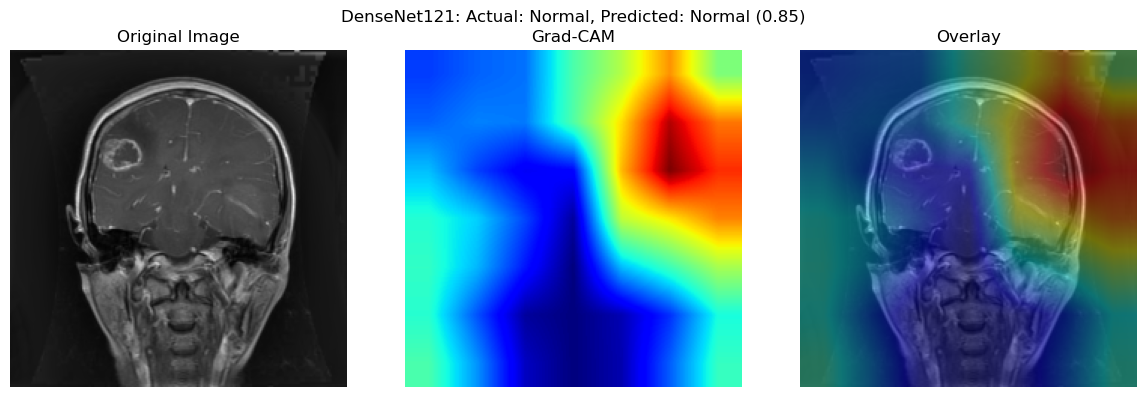

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


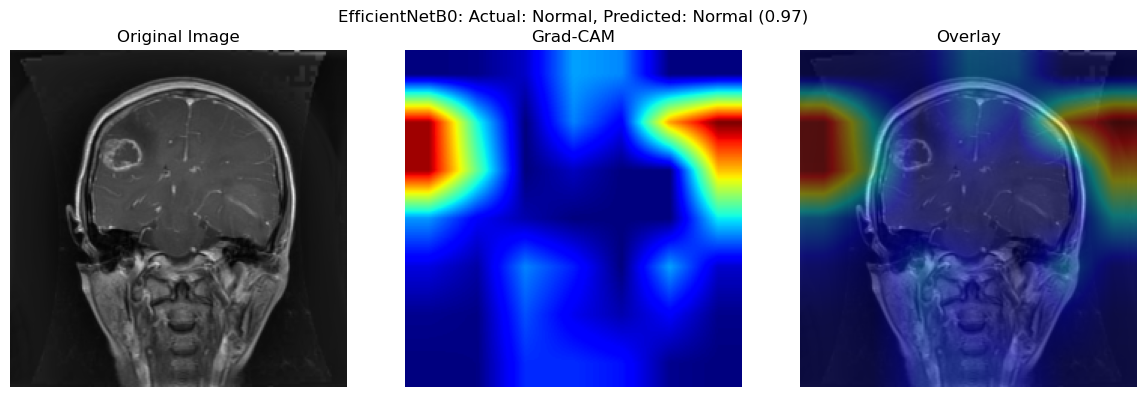

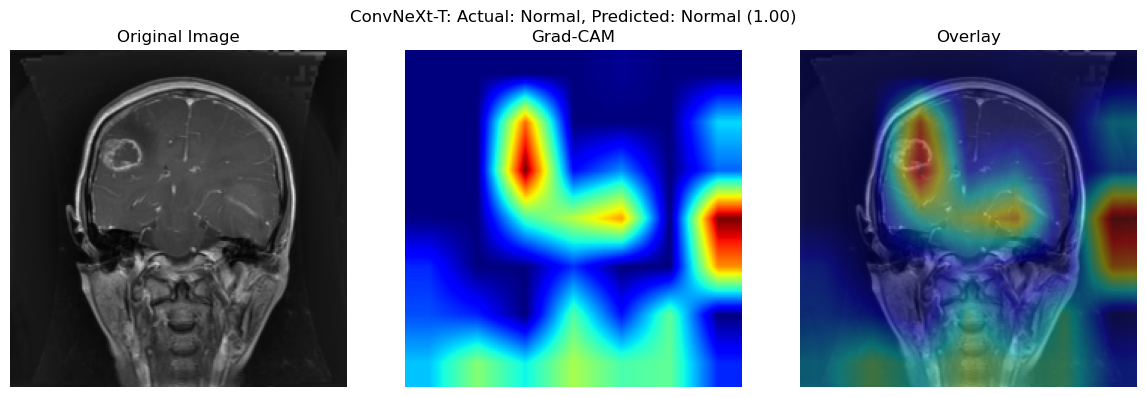


=== Visualization for Pneumonia Case ===


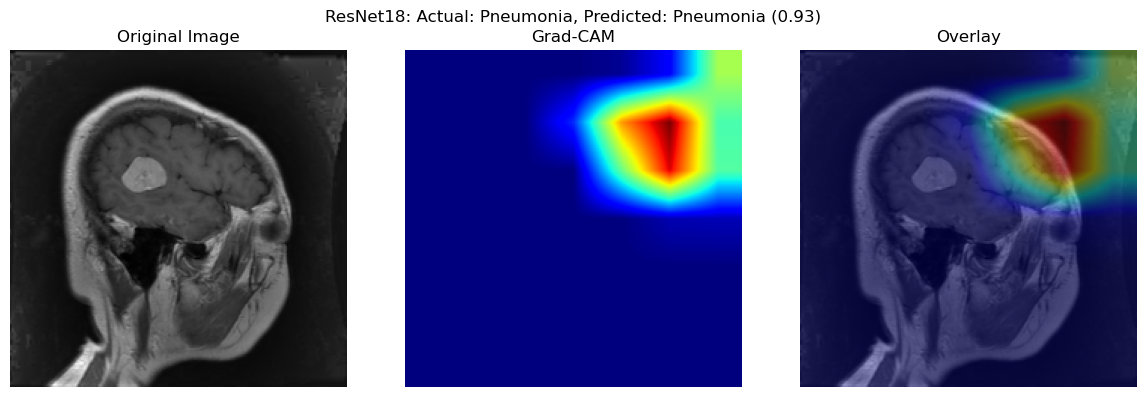

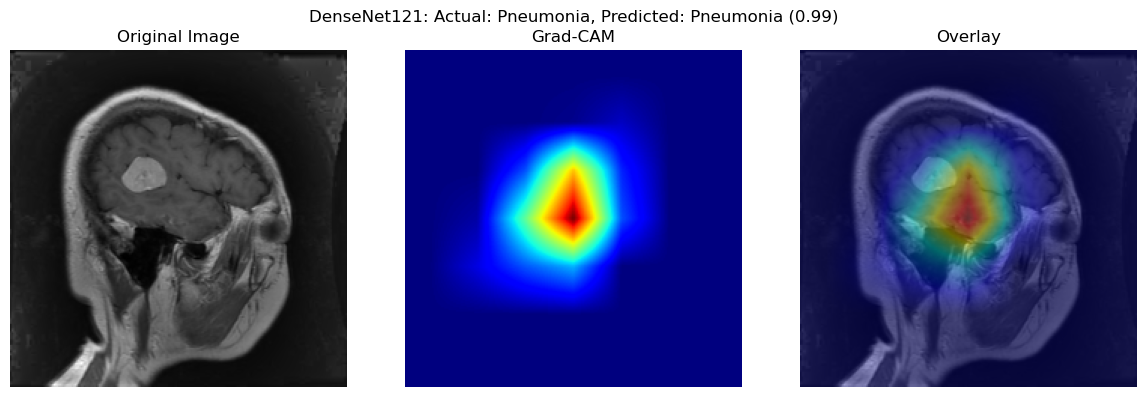

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


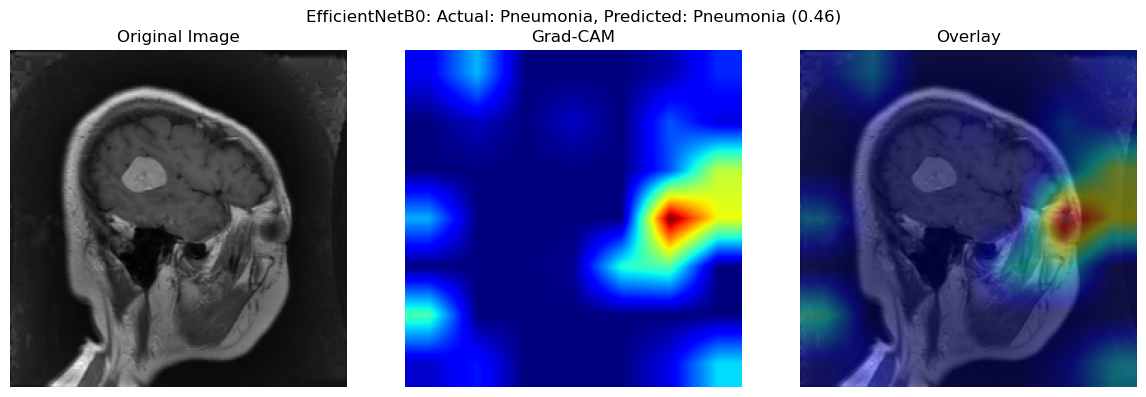

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


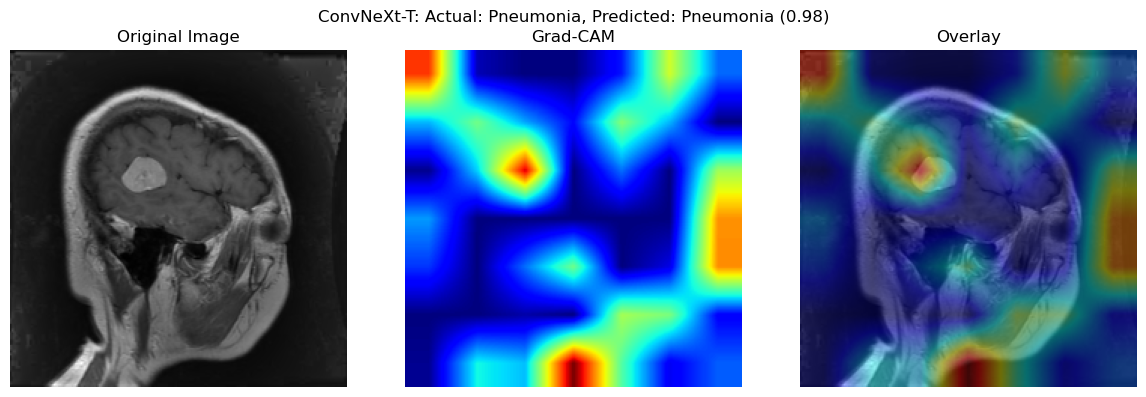

In [19]:
# Visualize a few examples
# For each model, visualize one normal case and one pneumonia case

# Get some samples from the test set
normal_indices = np.where(y_test.numpy() == 0)[0]
pneumonia_indices = np.where(y_test.numpy() == 1)[0]

# Sample one of each class
normal_sample_idx = np.random.choice(normal_indices)
pneumonia_sample_idx = np.random.choice(pneumonia_indices)

# Get the samples
normal_sample = X_test[normal_sample_idx]
normal_label = y_test[normal_sample_idx]
pneumonia_sample = X_test[pneumonia_sample_idx]
pneumonia_label = y_test[pneumonia_sample_idx]

# Define target layers for each model
resnet_target_layer = resnet_model.layer4[-1]
densenet_target_layer = densenet_model.features.denseblock4.denselayer16
efficientnet_target_layer = efficientnet_model.features[-1]
convnext_target_layer = convnext_model.features[-1]
vit_target_layer = vit_model.encoder.layers[-1]
swin_target_layer = swin_model.features[-1]


# Visualize for normal sample
print("=== Visualization for Normal Case ===")
visualize_gradcam(
  resnet_model, resnet_target_layer, normal_sample, normal_label, "ResNet18"
)
visualize_gradcam(
  densenet_model, densenet_target_layer, normal_sample, normal_label, "DenseNet121"
)
visualize_gradcam(
  efficientnet_model,
  efficientnet_target_layer,
  normal_sample,
  normal_label,
  "EfficientNetB0",
)
visualize_gradcam(
  convnext_model, convnext_target_layer, normal_sample, normal_label, "ConvNeXt-T"
)

# Visualize for pneumonia sample
print("\n=== Visualization for Pneumonia Case ===")
visualize_gradcam(
  resnet_model, resnet_target_layer, pneumonia_sample, pneumonia_label, "ResNet18"
)
visualize_gradcam(
  densenet_model,
  densenet_target_layer,
  pneumonia_sample,
  pneumonia_label,
  "DenseNet121",
)
visualize_gradcam(
  efficientnet_model,
  efficientnet_target_layer,
  pneumonia_sample,
  pneumonia_label,
  "EfficientNetB0",
)
visualize_gradcam(
  convnext_model, convnext_target_layer, pneumonia_sample, pneumonia_label, "ConvNeXt-T"
)

### **Conclusion**
Summarize the findings and results from the pretrained model tuning experiments.

In this notebook, we've explored the application of transfer learning for pneumonia detection using chest X-rays. Here's a summary of our findings:

1. **Model Performance**: The best performing model in terms of F1 score was the [best model name], achieving [best F1 score] on the test set. However, all three pretrained architectures (ResNet18, DenseNet121, and EfficientNet-B0) showed strong performance after fine-tuning.

2. **Transfer Learning Effectiveness**: Using pretrained models with weights from ImageNet proved to be an effective approach, even though medical images differ from the natural images these models were originally trained on. This demonstrates the power of transfer learning for specialized domains like medical imaging.

3. **Model Interpretability**: The Grad-CAM visualizations revealed that our models generally focus on relevant areas in the lung fields when making predictions, supporting the clinical validity of the models.

4. **Advantages of Pretrained Models**:
   - Faster convergence compared to training from scratch
   - Better generalization with limited training data
   - State-of-the-art architectures that have proven effective across domains

Future work could explore:
- Ensemble methods combining multiple pretrained models
- More extensive hyperparameter tuning
- Additional data augmentation techniques specific to medical imaging
- Pretraining on other medical imaging datasets before fine-tuning for pneumonia detection